<a href="https://colab.research.google.com/github/hanantaayp-code/BPJS-DATASET/blob/main/DATASET%20BPJS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import subprocess

# ==============================================================================
#@title LANGKAH 1: MENYIAPKAN DIREKTORI UTAMA
# ==============================================================================
from google.colab import drive
if not os.path.exists('/content/drive'):
    print("Mengaktifkan akses ke Google Drive...")
    drive.mount('/content/drive')

path_utama = '/content/drive/MyDrive/Data sampel bpjs'
path_output_induk = os.path.join(path_utama, 'Data_Sampel_Extracted')
os.makedirs(path_output_induk, exist_ok=True)

# ==============================================================================
# LANGKAH 2: INSTALASI PAKET PENDUKUNG SECARA OTOMATIS
# ==============================================================================
subprocess.run(['apt-get', 'install', '-y', 'unrar'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# ==============================================================================
# LANGKAH 3: DETEKSI BERKAS & EKSTRAKSI OTOMATIS
# ==============================================================================
# Memindai semua file ber-ekstensi .zip dan .rar di folder utama
daftar_arsip = glob.glob(os.path.join(path_utama, '*.zip')) + glob.glob(os.path.join(path_utama, '*.rar'))

print(f"\nDitemukan {len(daftar_arsip)} file kompresi yang siap diproses.")

for path_file in daftar_arsip:
    nama_file = os.path.basename(path_file)
    nama_murni, ekstensi = os.path.splitext(nama_file)

    # Otomatis membuat nama folder spesifik
    nama_folder_spesifik = nama_murni.replace(" ", "_")
    folder_tujuan = os.path.join(path_output_induk, nama_folder_spesifik)
    os.makedirs(folder_tujuan, exist_ok=True)

    print(f"\n[PROSES] Mengekstrak: {nama_file}")
    print(f"--> Target Folder: {folder_tujuan}")

    # Deteksi Otomatis Jenis File: ZIP
    if ekstensi.lower() == '.zip':
        # -n: skip extraction jika file sudah ada (anti-duplikasi)
        # -q: quiet mode agar log tidak memenuhi layar
        perintah = f'unzip -n -q "{path_file}" -d "{folder_tujuan}"'
        status = os.system(perintah)
        if status == 0:
            print(f"[SUKSES] Ekstraksi {nama_file} berhasil.")
        else:
            print(f"[GAGAL] Ada kendala saat mengekstrak {nama_file}.")

    # Deteksi Otomatis Jenis File: RAR
    elif ekstensi.lower() == '.rar':
        # x: ekstrak dengan struktur folder asli
        # -o-: skip extraction jika file sudah ada (anti-duplikasi)
        perintah = f'unrar x -o- "{path_file}" "{folder_tujuan}/"'
        status = os.system(perintah)
        if status == 0:
            print(f"[SUKSES] Ekstraksi {nama_file} berhasil.")
        else:
            print(f"[GAGAL] Ada kendala saat mengekstrak {nama_file}.")

print("\n=========================================================")
print("!!! PROSES EKSTRAKSI SEMUA BERKAS SELESAI !!!")
print(f"Semua hasil tersimpan di: {path_output_induk}")
print("=========================================================")

Mengaktifkan akses ke Google Drive...
Mounted at /content/drive

Ditemukan 5 file kompresi yang siap diproses.

[PROSES] Mengekstrak: Data sampel BPJS 2015-2024.zip
--> Target Folder: /content/drive/MyDrive/Data sampel bpjs/Data_Sampel_Extracted/Data_sampel_BPJS_2015-2024
[SUKSES] Ekstraksi Data sampel BPJS 2015-2024.zip berhasil.

[PROSES] Mengekstrak: Data Sampel 2015-2023.zip
--> Target Folder: /content/drive/MyDrive/Data sampel bpjs/Data_Sampel_Extracted/Data_Sampel_2015-2023
[SUKSES] Ekstraksi Data Sampel 2015-2023.zip berhasil.

[PROSES] Mengekstrak: Data Sampel 2015-2022.rar
--> Target Folder: /content/drive/MyDrive/Data sampel bpjs/Data_Sampel_Extracted/Data_Sampel_2015-2022
[GAGAL] Ada kendala saat mengekstrak Data Sampel 2015-2022.rar.

[PROSES] Mengekstrak: Data Sampel 2015-2021(1).rar
--> Target Folder: /content/drive/MyDrive/Data sampel bpjs/Data_Sampel_Extracted/Data_Sampel_2015-2021(1)
[SUKSES] Ekstraksi Data Sampel 2015-2021(1).rar berhasil.

[PROSES] Mengekstrak: Data 

In [ ]:
#@title LANGKAH 2 CHECKING NAMA FILE DAN LETAK DATA
import os
path_output_induk = '/content/drive/MyDrive/Data sampel bpjs/Data_Sampel_Extracted'

MAX_FILES_PER_DIR = 30

# Mengecek apakah folder utama ada
if os.path.exists(path_output_induk):
    for root, dirs, files in os.walk(path_output_induk):

        level = root.replace(path_output_induk, '').count(os.sep)
        indent = ' ' * 4 * level

        # Nama folder saat ini
        nama_folder = os.path.basename(root)
        if nama_folder == '':
            nama_folder = 'Data_Sampel_Extracted (ROOT)'

        print(f"{indent}📂 {nama_folder}/")


        subindent = ' ' * 4 * (level + 1)

        files.sort()

        # Print nama-nama file
        for i, f in enumerate(files):
            if i < MAX_FILES_PER_DIR:
                print(f"{subindent}📄 {f}")
            elif i == MAX_FILES_PER_DIR:
                print(f"{subindent}⚠️ ... dan {len(files) - MAX_FILES_PER_DIR} file lainnya (disembunyikan agar output tidak kepanjangan)")
                break
else:
    print(f"[ERROR] Folder {path_output_induk} tidak ditemukan.")

📂 Data_Sampel_Extracted/
    📂 Data Sampel Final 2022/
        📂 Kontekstual DM/
            📄 2022 Metadata Data Sampel BPJS Kesehatan.xlsx
            📄 DM2019_kepesertaan.dta
            📄 DM2020_kepesertaan.dta
            📄 DM2021_fkrtl.dta
            📄 DM2021_fkrtldxsekunder.dta
            📄 DM2021_fktpkapitasi.dta
            📄 DM2021_fktpnonkapitasi.dta
            📄 DM2021_kepesertaan.dta
            📂 Dofiles/
                📄 1_kepesertaan.do
                📄 2_fktp_kapitasi.do
                📄 3_fkrtl.do
                📄 4_fktp_nonkapitasi.do
            📂 Kode diagnosis ICD10/
                📄 2021 Kode ICD10 untuk diagnosis FKRTL.xlsx
                📄 2021 Kode ICD10 untuk diagnosis FKTP Kapitasi.xlsx
                📄 2021 Kode ICD10 untuk diagnosis FKTP Non Kapitasi.xlsx
        📂 Kontekstual TB/
            📄 2022 Metadata Data Sampel BPJS Kesehatan.xlsx
            📄 TB20152021_fkrtl.dta
            📄 TB20152021_fkrtldxsekunder.dta
            📄 TB20152021_fkt

In [ ]:
#@title 3 MENGUMPULKAN SELURUH DATA YANG DIPERLUKAN
import os
import glob
import shutil

path_induk = '/content/drive/MyDrive/Data sampel bpjs/Data_Sampel_Extracted'
path_staging = '/content/drive/MyDrive/Data sampel bpjs/Staging_Data_Panel'
os.makedirs(path_staging, exist_ok=True)


# ---------------------------------------------------------
# TAHAP 1: Ekstrak ZIP 2015-2020
# ---------------------------------------------------------
zip_2015_2020 = glob.glob(f"{path_induk}/Data_Sampel_2015-2020/*Reguler*.zip")
if zip_2015_2020:
    target_zip = zip_2015_2020[0]
    folder_ekstrak_2015_2020 = os.path.join(path_induk, 'Data_Sampel_2015-2020_Extracted')
    os.makedirs(folder_ekstrak_2015_2020, exist_ok=True)

    os.system(f'unzip -n -q "{target_zip}" -d "{folder_ekstrak_2015_2020}"')
    print("[EKSTRAKSI] Selesai.\n")

# ---------------------------------------------------------
# TAHAP 2: File Master Kepesertaan Ultimate
# ---------------------------------------------------------
pola_kepesertaan = glob.glob(f"{path_induk}/**/2015202401_kepesertaan.dta", recursive=True)
if pola_kepesertaan:
    print(f"[KONSOLIDASI] Memindahkan Filw Master Kepesertaan...")
    shutil.copy2(pola_kepesertaan[0], os.path.join(path_staging, '2015202401_kepesertaan.dta'))

# ---------------------------------------------------------
# TAHAP 3: FKTP FKRTL REG)
# ---------------------------------------------------------
print("[KONSOLIDASI] Menyisir  file FKTP & FKRTL Reguler...")

# Mencari semua file .dta di semua sub-folder
semua_dta = glob.glob(f"{path_induk}/**/*.dta", recursive=True)
file_terkumpul = 0

for file_path in semua_dta:
    # Filter ketat: Abaikan folder MACOSX
    if '__MACOSX' in file_path or 'Kontekstual' in file_path:
        continue

    nama_file = os.path.basename(file_path)

    # Hanya ambil file yang berakhiran fktpkapitasi.dta atau fkrtl.dta
    if nama_file.endswith('02_fktpkapitasi.dta') or nama_file.endswith('03_fkrtl.dta'):
        target_path = os.path.join(path_staging, nama_file)

        # Copy file jika belum ada di folder staging
        if not os.path.exists(target_path):
            shutil.copy2(file_path, target_path)
            file_terkumpul += 1
            print(f"  -> Tersalin: {nama_file}")

[EKSTRAKSI] Selesai.

[KONSOLIDASI] Memindahkan Filw Master Kepesertaan...
[KONSOLIDASI] Menyisir  file FKTP & FKRTL Reguler...
  -> Tersalin: Copy of 202302_fktpkapitasi.dta
  -> Tersalin: Copy of 202303_fkrtl.dta


In [ ]:
#@title  4 CLEANING DAN AGREGASI DATA
import os
import glob
import pandas as pd
import numpy as np
import re
import shutil

# ==============================================================================
# LANGKAH 1: KONFIGURASI DIREKTORI & PEMBERSIHAN AWAL
# ==============================================================================
path_staging = '/content/drive/MyDrive/Data sampel bpjs/Staging_Data_Panel'
path_processed = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed'
path_partitions = os.path.join(path_processed, 'raw_partitions')
path_output_final = os.path.join(path_processed, 'Panel_Tahunan_Robust')

# membersihkan folder partisi sisa run sebelumnya agar data tidak dobel
if os.path.exists(path_partitions):
    shutil.rmtree(path_partitions)
os.makedirs(path_partitions, exist_ok=True)
os.makedirs(path_output_final, exist_ok=True)

file_kepesertaan = os.path.join(path_staging, '2015202401_kepesertaan.dta')

#Data Kepesertaan
if os.path.exists(file_kepesertaan):
    kolom_peserta = ['PSTV01', 'PSTV03', 'PSTV05', 'PSTV09', 'PSTV10']
    df_master_kepesertaan = pd.read_stata(file_kepesertaan, columns=kolom_peserta)
    df_master_kepesertaan['PSTV01'] = df_master_kepesertaan['PSTV01'].astype(str).str.strip()
    df_master_kepesertaan = df_master_kepesertaan.drop_duplicates(subset=['PSTV01'])
    print(f"[SUKSES] Master Kepesertaan Siap. Total individu: {len(df_master_kepesertaan):,}")
else:
    raise FileNotFoundError(f"File Kepesertaan tidak ditemukan.")

# ==============================================================================
# LANGKAH 2: DATA FKTP
# ==============================================================================

files_fktp = glob.glob(os.path.join(path_staging, '*02_fktp*.dta'))

for f_path in files_fktp:
    print(f"\n[MEMBONGKAR] Menyisir data riil dari: {os.path.basename(f_path)}")
    with pd.read_stata(f_path, columns=['PSTV01', 'FKP03', 'FKP14A'], chunksize=500000, iterator=True) as reader:
        for chunk in reader:
            chunk = chunk.dropna(subset=['PSTV01', 'FKP03'])
            chunk['TAHUN_PELAYANAN'] = pd.to_datetime(chunk['FKP03'], errors='coerce').dt.year
            chunk = chunk.dropna(subset=['TAHUN_PELAYANAN'])
            chunk['TAHUN_PELAYANAN'] = chunk['TAHUN_PELAYANAN'].astype(int)

            chunk['PSTV01'] = chunk['PSTV01'].astype(str).str.strip()
            # Konversi ke object dulu agar format Stata lepas
            chunk['FKP14A'] = chunk['FKP14A'].astype(object).fillna('').astype(str).str.upper().str.strip()

            for thn, sub_df in chunk.groupby('TAHUN_PELAYANAN'):
                out_file = os.path.join(path_partitions, f'fktp_raw_{thn}.csv')
                is_first = not os.path.exists(out_file)
                sub_df[['PSTV01', 'FKP14A']].to_csv(out_file, index=False, mode='a', header=is_first)

# ==============================================================================
# LANGKAH 3: DATA FKRTL
# ==============================================================================
files_fkrtl = glob.glob(os.path.join(path_staging, '*03_fkrtl*.dta'))

for r_path in files_fkrtl:
    print(f"\n[MEMBONGKAR] Menyisir data riil dari: {os.path.basename(r_path)}")
    kolom_r = ['PSTV01', 'FKL03', 'FKL10', 'FKL17A', 'FKL44', 'FKL48']

    with pd.read_stata(r_path, columns=kolom_r, chunksize=500000, iterator=True) as reader:
        for chunk in reader:
            chunk = chunk.dropna(subset=['PSTV01', 'FKL03'])
            chunk['TAHUN_PELAYANAN'] = pd.to_datetime(chunk['FKL03'], errors='coerce').dt.year
            chunk = chunk.dropna(subset=['TAHUN_PELAYANAN'])
            chunk['TAHUN_PELAYANAN'] = chunk['TAHUN_PELAYANAN'].astype(int)

            chunk['PSTV01'] = chunk['PSTV01'].astype(str).str.strip()

            # REVISI: .astype(object) untuk menetralkan "categorical error" dari Stata
            chunk['FKL17A'] = chunk['FKL17A'].astype(object).fillna('').astype(str).str.upper().str.strip()
            chunk['FKL44'] = chunk['FKL44'].astype(object).fillna('').astype(str).str.upper().str.strip()
            chunk['FKL10'] = chunk['FKL10'].astype(object).fillna('').astype(str).str.upper().str.strip()

            chunk['FKL48'] = pd.to_numeric(chunk['FKL48'], errors='coerce').fillna(0)

            for thn, sub_df in chunk.groupby('TAHUN_PELAYANAN'):
                out_file = os.path.join(path_partitions, f'fkrtl_raw_{thn}.csv')
                is_first = not os.path.exists(out_file)
                sub_df[['PSTV01', 'FKL10', 'FKL17A', 'FKL44', 'FKL48']].to_csv(out_file, index=False, mode='a', header=is_first)

# ==============================================================================
# LANGKAH 4: AGREGASI INDIVIDU, & MATRIKS PANEL
# ==============================================================================
print("\n=========================================================")
print("4. MEMULAI AGREGASI INDIVIDU & HARMONISASI PANEL AKHIR...")
print("=========================================================")

semua_raw_files = os.listdir(path_partitions)
tahun_terdeteksi = set()
for f in semua_raw_files:
    match = re.search(r'\d+', f)
    if match:
        tahun_terdeteksi.add(int(match.group()))

for thn in sorted(list(tahun_terdeteksi)):
    if thn < 2015:
        continue

    print(f"\n--- Memproses Hasil Akhir untuk Tahun Analisis: {thn} ---")
    file_f_raw = os.path.join(path_partitions, f'fktp_raw_{thn}.csv')
    file_r_raw = os.path.join(path_partitions, f'fkrtl_raw_{thn}.csv')

    #  data FKTP
    if os.path.exists(file_f_raw):
        df_f = pd.read_csv(file_f_raw, dtype={'PSTV01': str})
        df_f['FKP14A'] = df_f['FKP14A'].fillna('')
        df_f = df_f.groupby('PSTV01').agg({
            'FKP14A': lambda x: '|'.join(set([i for i in '|'.join(x.astype(str)).split('|') if i and i not in ['NAN', 'NONE']]))
        }).reset_index()
    else:
        df_f = pd.DataFrame(columns=['PSTV01', 'FKP14A'])

    #  data FKRTL
    if os.path.exists(file_r_raw):
        df_r = pd.read_csv(file_r_raw, dtype={'PSTV01': str})
        df_r['FKL17A'] = df_r['FKL17A'].fillna('')
        df_r['FKL44'] = df_r['FKL44'].fillna('')
        df_r['FKL10'] = df_r['FKL10'].fillna('RJTL')
        df_r = df_r.groupby('PSTV01').agg({
            'FKL17A': lambda x: '|'.join(set([i for i in '|'.join(x.astype(str)).split('|') if i and i not in ['NAN', 'NONE']])),
            'FKL44': lambda x: '|'.join(set([i for i in '|'.join(x.astype(str)).split('|') if i and i not in ['NAN', 'NONE']])),
            'FKL10': 'first',
            'FKL48': 'sum'
        }).reset_index()
        df_r = df_r.rename(columns={'FKL48': 'TOTAL_BIAYA_FKRTL'})
    else:
        df_r = pd.DataFrame(columns=['PSTV01', 'FKL17A', 'FKL44', 'FKL10', 'TOTAL_BIAYA_FKRTL'])

    # Satukan
    df_med = pd.merge(df_f, df_r, on='PSTV01', how='outer')
    df_med['TAHUN_PELAYANAN'] = thn

    df_med['FKP14A'] = df_med['FKP14A'].replace('', np.nan).fillna('TIDAK_ADA_KUNJUNGAN')
    df_med['FKL17A'] = df_med['FKL17A'].replace('', np.nan).fillna('TIDAK_ADA_KUNJUNGAN')
    df_med['FKL44'] = df_med['FKL44'].replace('', np.nan).fillna('TIDAK_ADA_OBAT_KHUSUS')
    df_med['TOTAL_BIAYA_FKRTL'] = df_med['TOTAL_BIAYA_FKRTL'].fillna(0)

    df_med = df_med[~((df_med['FKP14A'] == 'TIDAK_ADA_KUNJUNGAN') & (df_med['FKL17A'] == 'TIDAK_ADA_KUNJUNGAN'))]
    df_final_tahun = pd.merge(df_med, df_master_kepesertaan, on='PSTV01', how='inner')

    susunan_kolom = ['PSTV01', 'TAHUN_PELAYANAN', 'FKP14A', 'FKL17A', 'FKL44', 'FKL10', 'TOTAL_BIAYA_FKRTL', 'PSTV03', 'PSTV05', 'PSTV09', 'PSTV10']
    df_final_tahun = df_final_tahun[[col for col in susunan_kolom if col in df_final_tahun.columns]]

    nama_file_final = os.path.join(path_output_final, f'panel_robust_{thn}.csv')
    df_final_tahun.to_csv(nama_file_final, index=False)
    print(f"  -> [BERHASIL] File 'panel_robust_{thn}.csv' matang dengan {len(df_final_tahun):,} baris.")

shutil.rmtree(path_partitions)

[SUKSES] Master Kepesertaan Siap. Total individu: 2,590,751

[MEMBONGKAR] Menyisir data riil dari: 2019202002_fktpkapitasi.dta

[MEMBONGKAR] Menyisir data riil dari: 202102_fktpkapitasi.dta

[MEMBONGKAR] Menyisir data riil dari: 202302_fktpkapitasi.dta

[MEMBONGKAR] Menyisir data riil dari: 202402_fktpkapitasi.dta

[MEMBONGKAR] Menyisir data riil dari: 202202_fktpkapitasi.dta

[MEMBONGKAR] Menyisir data riil dari: Copy of 202302_fktpkapitasi.dta

[MEMBONGKAR] Menyisir data riil dari: 2019202003_fkrtl.dta

[MEMBONGKAR] Menyisir data riil dari: 202103_fkrtl.dta

[MEMBONGKAR] Menyisir data riil dari: 202303_fkrtl.dta

[MEMBONGKAR] Menyisir data riil dari: 202403_fkrtl.dta

[MEMBONGKAR] Menyisir data riil dari: 202203_fkrtl.dta

[MEMBONGKAR] Menyisir data riil dari: Copy of 202303_fkrtl.dta

4. MEMULAI AGREGASI INDIVIDU & HARMONISASI PANEL AKHIR...

--- Memproses Hasil Akhir untuk Tahun Analisis: 2018 ---
  -> [BERHASIL] File 'panel_robust_2018.csv' matang dengan 1,012 baris.

--- Memprose

/tmp/ipykernel_4257/193536199.py:113: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_f = pd.read_csv(file_f_raw, dtype={'PSTV01': str})


  -> [BERHASIL] File 'panel_robust_2019.csv' matang dengan 592,698 baris.

--- Memproses Hasil Akhir untuk Tahun Analisis: 2020 ---


/tmp/ipykernel_4257/193536199.py:113: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_f = pd.read_csv(file_f_raw, dtype={'PSTV01': str})


  -> [BERHASIL] File 'panel_robust_2020.csv' matang dengan 526,651 baris.

--- Memproses Hasil Akhir untuk Tahun Analisis: 2021 ---


...

  -> [BERHASIL] File 'panel_robust_2021.csv' matang dengan 518,750 baris.

--- Memproses Hasil Akhir untuk Tahun Analisis: 2022 ---


/tmp/ipykernel_4257/193536199.py:113: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_f = pd.read_csv(file_f_raw, dtype={'PSTV01': str})


  -> [BERHASIL] File 'panel_robust_2022.csv' matang dengan 635,985 baris.

--- Memproses Hasil Akhir untuk Tahun Analisis: 2023 ---


/tmp/ipykernel_4257/193536199.py:113: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_f = pd.read_csv(file_f_raw, dtype={'PSTV01': str})


  -> [BERHASIL] File 'panel_robust_2023.csv' matang dengan 709,586 baris.

--- Memproses Hasil Akhir untuk Tahun Analisis: 2024 ---
  -> [BERHASIL] File 'panel_robust_2024.csv' matang dengan 769,569 baris.


In [ ]:
#@title 5 JUMLAH BARIS PANEL FINAL
import pandas as pd
import glob
import os

path_final = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Panel_Tahunan_Robust'
files = sorted(glob.glob(os.path.join(path_final, 'panel_robust_*.csv')))

for f in files:
    # Hanya membaca 1 kolom t
    df = pd.read_csv(f, usecols=['PSTV01'])
    print(f"-> {os.path.basename(f).ljust(25)} : {len(df):,} baris")



        INSPEKSI JUMLAH BARIS PANEL FINAL                

-> panel_robust_2018.csv     : 1,012 baris
-> panel_robust_2019.csv     : 592,698 baris
-> panel_robust_2020.csv     : 488,854 baris
-> panel_robust_2021.csv     : 518,510 baris
-> panel_robust_2022.csv     : 635,985 baris
-> panel_robust_2023.csv     : 709,586 baris
-> panel_robust_2024.csv     : 769,569 baris



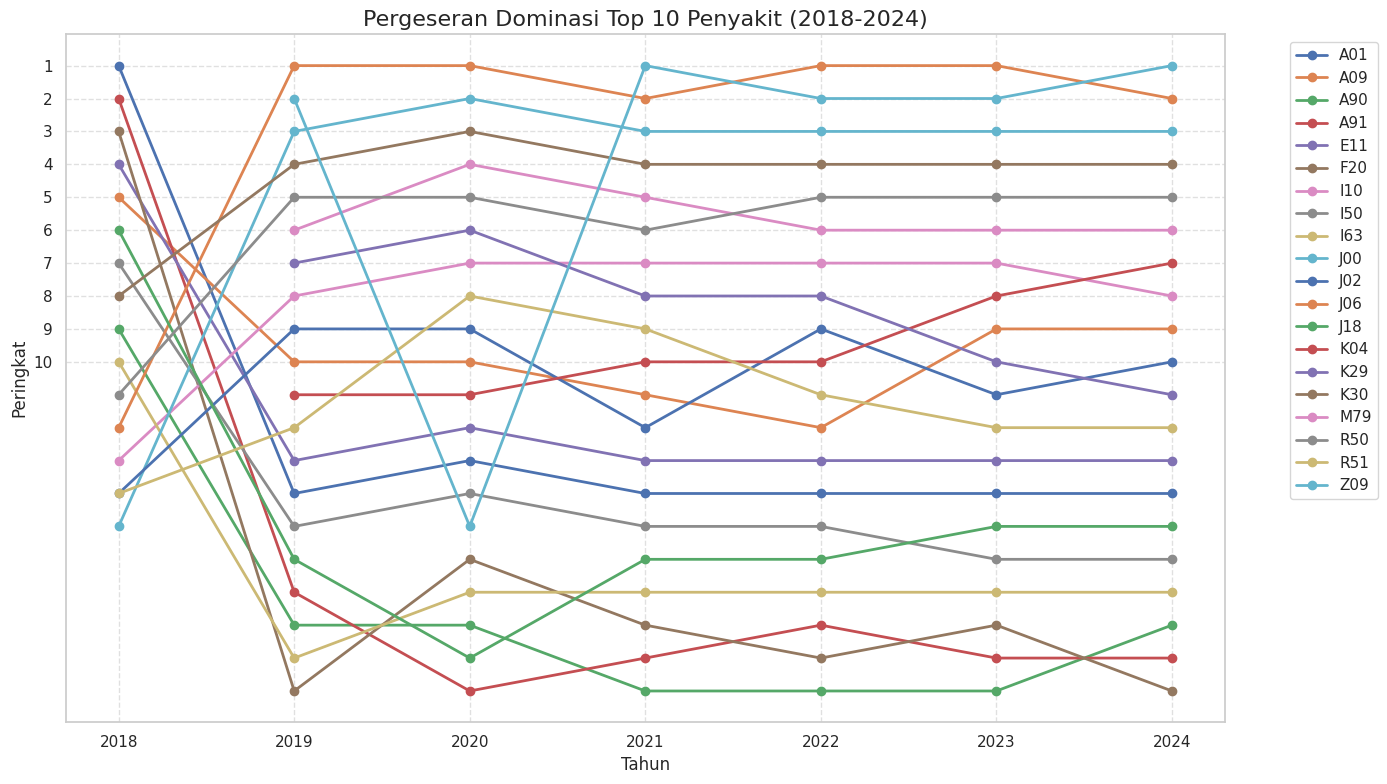

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#@title 6 PERGESERAN PENYAKIT

# 1. Identifikasi penyakit yang PERNAH masuk Top 10 di tahun manapun
top_10_list = df_summary.groupby('TAHUN').apply(lambda x: x.nlargest(10, 'COUNT'))['ICD10_CODE'].unique()

# 2. Filter data utama hanya untuk penyakit-penyakit tersebut
df_filtered = df_summary[df_summary['ICD10_CODE'].isin(top_10_list)].copy()

# 3. Buat Peringkat (Rank) per Tahun
df_filtered['RANK'] = df_filtered.groupby('TAHUN')['COUNT'].rank(method='dense', ascending=False)

# 4. Pivot data untuk Bump Chart
df_bump = df_filtered.pivot(index='ICD10_CODE', columns='TAHUN', values='RANK')

# 5. Visualisasi Bump Chart
plt.figure(figsize=(14, 8))
for icd_code in df_bump.index:
    plt.plot(df_bump.columns, df_bump.loc[icd_code], marker='o', linewidth=2, label=icd_code)

plt.gca().invert_yaxis() # Peringkat 1 harus di atas
plt.yticks(range(1, 11))
plt.title('Pergeseran Dominasi Top 10 Penyakit (2018-2024)', fontsize=16)
plt.ylabel('Peringkat')
plt.xlabel('Tahun')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
#@title RANK berdasarkan CH
# 1. Definisikan fungsi untuk menentukan Chapter berdasarkan kode ICD
def get_chapter(code):
    first_char = code[0].upper()
    mapping = {
        'A': 'I', 'B': 'I', 'C': 'II', 'D': 'II/III', 'E': 'IV', 'F': 'V',
        'G': 'VI', 'H': 'VII/VIII', 'I': 'IX', 'J': 'X', 'K': 'XI',
        'L': 'XII', 'M': 'XIII', 'N': 'XIV', 'O': 'XV', 'P': 'XVI',
        'Q': 'XVII', 'R': 'XVIII', 'S': 'XIX', 'T': 'XIX', 'U': 'XXII'
    }
    # Perhatikan: Kategori 'Z' sengaja tidak dimasukkan agar mudah di-filter
    return mapping.get(first_char, 'Other')

# 2. Buat DataFrame baru dengan Chapter, tanpa 'Z'
df_clean = df_summary[~df_summary['ICD10_CODE'].str.startswith('Z')].copy()
df_clean['CHAPTER'] = df_clean['ICD10_CODE'].apply(get_chapter)

# 3. Agregasikan COUNT berdasarkan CHAPTER per TAHUN
df_grouped = df_clean.groupby(['TAHUN', 'CHAPTER'])['COUNT'].sum().reset_index()

# 4. Ambil Top 3 per tahun
top_3_per_tahun = df_grouped.sort_values(['TAHUN', 'COUNT'], ascending=[True, False]) \
                            .groupby('TAHUN').head(3)

print(top_3_per_tahun)

    TAHUN CHAPTER   COUNT
0    2018       I     216
4    2018      IX     144
14   2018      XV     112
27   2019       X  320296
28   2019      XI  219633
36   2019   XVIII  147350
47   2020       X  219149
48   2020      XI  158282
56   2020   XVIII  107998
67   2021       X  227399
68   2021      XI  180173
76   2021   XVIII  126423
87   2022       X  360904
88   2022      XI  228426
96   2022   XVIII  172672
107  2023       X  394027
108  2023      XI  274232
116  2023   XVIII  197788
127  2024       X  406198
128  2024      XI  293557
136  2024   XVIII  224103


In [ ]:
import pandas as pd
import glob
import os
#@title 7 DATA SET BERDASARKAN KASUS
path_staging = '/content/drive/MyDrive/Data sampel bpjs/Staging_Data_Panel'
path_processed = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed'

print("=========================================================")
print("  EKSTRAKSI TREN PENYAKIT BULANAN (CASE-BASED) UNTUK OBAT")
print("=========================================================\n")

list_monthly_cases = []

# ---------------------------------------------------------
# 1. TARIK DATA KUNJUNGAN FKTP (PUSKESMAS/KLINIK)
# ---------------------------------------------------------
files_fktp = glob.glob(os.path.join(path_staging, '*02_fktp*.dta'))
for f in files_fktp:
    print(f"[PROSES] Mengekstrak bulan kunjungan dari: {os.path.basename(f)}")
    with pd.read_stata(f, columns=['FKP03', 'FKP14A'], chunksize=500000, iterator=True) as reader:
        for chunk in reader:
            chunk = chunk.dropna(subset=['FKP03', 'FKP14A'])
            # Ambil format Tahun-Bulan (YYYY-MM)
            chunk['BULAN_KUNJUNGAN'] = pd.to_datetime(chunk['FKP03'], errors='coerce').dt.to_period('M')
            chunk = chunk.dropna(subset=['BULAN_KUNJUNGAN'])

            # Ekstrak 3 digit ICD-10
            chunk['ICD10_3D'] = chunk['FKP14A'].astype(str).str.upper().str.strip().str[:3]

            # Hitung jumlah kasus per Bulan per Kode Penyakit
            agregat = chunk.groupby(['BULAN_KUNJUNGAN', 'ICD10_3D']).size().reset_index(name='JUMLAH_KASUS')
            list_monthly_cases.append(agregat)

# ---------------------------------------------------------
# 2. TARIK DATA KUNJUNGAN FKRTL (RUMAH SAKIT)
# ---------------------------------------------------------
files_fkrtl = glob.glob(os.path.join(path_staging, '*03_fkrtl*.dta'))
for f in files_fkrtl:
    print(f"[PROSES] Mengekstrak bulan kunjungan dari: {os.path.basename(f)}")
    with pd.read_stata(f, columns=['FKL03', 'FKL17A'], chunksize=500000, iterator=True) as reader:
        for chunk in reader:
            chunk = chunk.dropna(subset=['FKL03', 'FKL17A'])
            chunk['BULAN_KUNJUNGAN'] = pd.to_datetime(chunk['FKL03'], errors='coerce').dt.to_period('M')
            chunk = chunk.dropna(subset=['BULAN_KUNJUNGAN'])

            chunk['ICD10_3D'] = chunk['FKL17A'].astype(str).str.upper().str.strip().str[:3]
            agregat = chunk.groupby(['BULAN_KUNJUNGAN', 'ICD10_3D']).size().reset_index(name='JUMLAH_KASUS')
            list_monthly_cases.append(agregat)

# ---------------------------------------------------------
# 3. KONSOLIDASI FINAL TREN BULANAN
# ---------------------------------------------------------
print("\n[KONSOLIDASI] Menyatukan dan menghitung total kasus bulanan...")
df_all_cases = pd.concat(list_monthly_cases)

df_trend_bulanan = df_all_cases.groupby(['BULAN_KUNJUNGAN', 'ICD10_3D'])['JUMLAH_KASUS'].sum().reset_index()

# Konversi kolom period kembali ke string agar mudah disimpan ke CSV
df_trend_bulanan['BULAN_KUNJUNGAN'] = df_trend_bulanan['BULAN_KUNJUNGAN'].astype(str)

# Urutkan berdasarkan waktu
df_trend_bulanan = df_trend_bulanan.sort_values(['BULAN_KUNJUNGAN', 'JUMLAH_KASUS'], ascending=[True, False])

# Simpan hasilnya
out_path = os.path.join(path_processed, 'Tren_Penyakit_Bulanan.csv')
df_trend_bulanan.to_csv(out_path, index=False)

print(f"\n[SUKSES] Data tren bulanan berhasil dibuat!")
print(f"File tersimpan di: {out_path}")
print("\nPreview 5 baris teratas:")
print(df_trend_bulanan.head(260))

  EKSTRAKSI TREN PENYAKIT BULANAN (CASE-BASED) UNTUK OBAT

[PROSES] Mengekstrak bulan kunjungan dari: 202102_fktpkapitasi.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202402_fktpkapitasi.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202302_fktpkapitasi.dta
[PROSES] Mengekstrak bulan kunjungan dari: 2019202002_fktpkapitasi.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202202_fktpkapitasi.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202103_fkrtl.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202403_fkrtl.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202303_fkrtl.dta
[PROSES] Mengekstrak bulan kunjungan dari: 2019202003_fkrtl.dta
[PROSES] Mengekstrak bulan kunjungan dari: 202203_fkrtl.dta

[KONSOLIDASI] Menyatukan dan menghitung total kasus bulanan...

[SUKSES] Data tren bulanan berhasil dibuat!
File tersimpan di: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Tren_Penyakit_Bulanan.csv

Preview 5 baris teratas:
  BULAN_KUNJUNGAN ICD10_3D  JUMLAH_KASUS
0         2018-04     

  VISUALIZATION: DISEASE BURDEN BY ICD-10 CHAPTER (EN)   

[PROCESS] Mapping ICD-10 codes to official chapters...

--- SUMMARY TABLE: CHAPTER SHARE (%) ---


CHAPTER,X: Respiratory System,XI: Digestive System,XVIII: Symptoms & Signs,I: Infectious & Parasitic,IX: Circulatory System,XIII: Musculoskeletal,VII/VIII: Eye & Ear,XII: Skin & Subcutaneous,XV: Pregnancy & Childbirth,"IV: Endocrine, Nutritional & Metabolic",XIV: Genitourinary System,II/III: Neoplasms & Blood,XIX: Injury & Poisoning,VI: Nervous System,V: Mental & Behavioural,XVI: Perinatal Conditions,XVII: Congenital Malformations,Other/Unclassified
TAHUN,,,,,,,,,,,,,,,,,,
2018,8.05,9.66,2.72,21.73,14.49,1.41,0.80,0.60,11.27,5.53,5.63,6.14,3.12,1.81,4.83,1.61,0.60,0.0
2019,22.72,15.58,10.45,7.97,6.95,8.06,7.05,4.88,3.48,3.08,2.63,1.90,2.33,1.67,0.46,0.40,0.20,0.0
2020,23.17,16.73,11.42,6.71,7.13,9.63,5.55,6.07,2.31,3.22,2.05,1.26,1.99,1.84,0.47,0.09,0.15,0.0
2021,20.07,15.90,11.16,6.66,7.62,8.74,6.32,5.19,3.99,3.60,2.64,1.96,2.28,1.96,0.64,0.89,0.22,0.0
2022,24.11,15.26,11.54,6.94,6.68,8.14,6.53,4.65,3.18,3.32,2.47,1.87,2.18,1.78,0.61,0.42,0.21,0.0
2023,22.80,15.87,11.45,7.11,6.77,8.16,6.48,4.89,2.86,3.61,2.63,1.86,2.33,1.82,0.65,0.37,0.19,0.0
2024,21.47,15.51,11.84,7.91,6.83,8.03,6.68,4.93,2.63,3.75,2.80,1.79,2.51,1.95,0.70,0.33,0.17,0.0



[PROCESS] Rendering Stacked Area Chart...


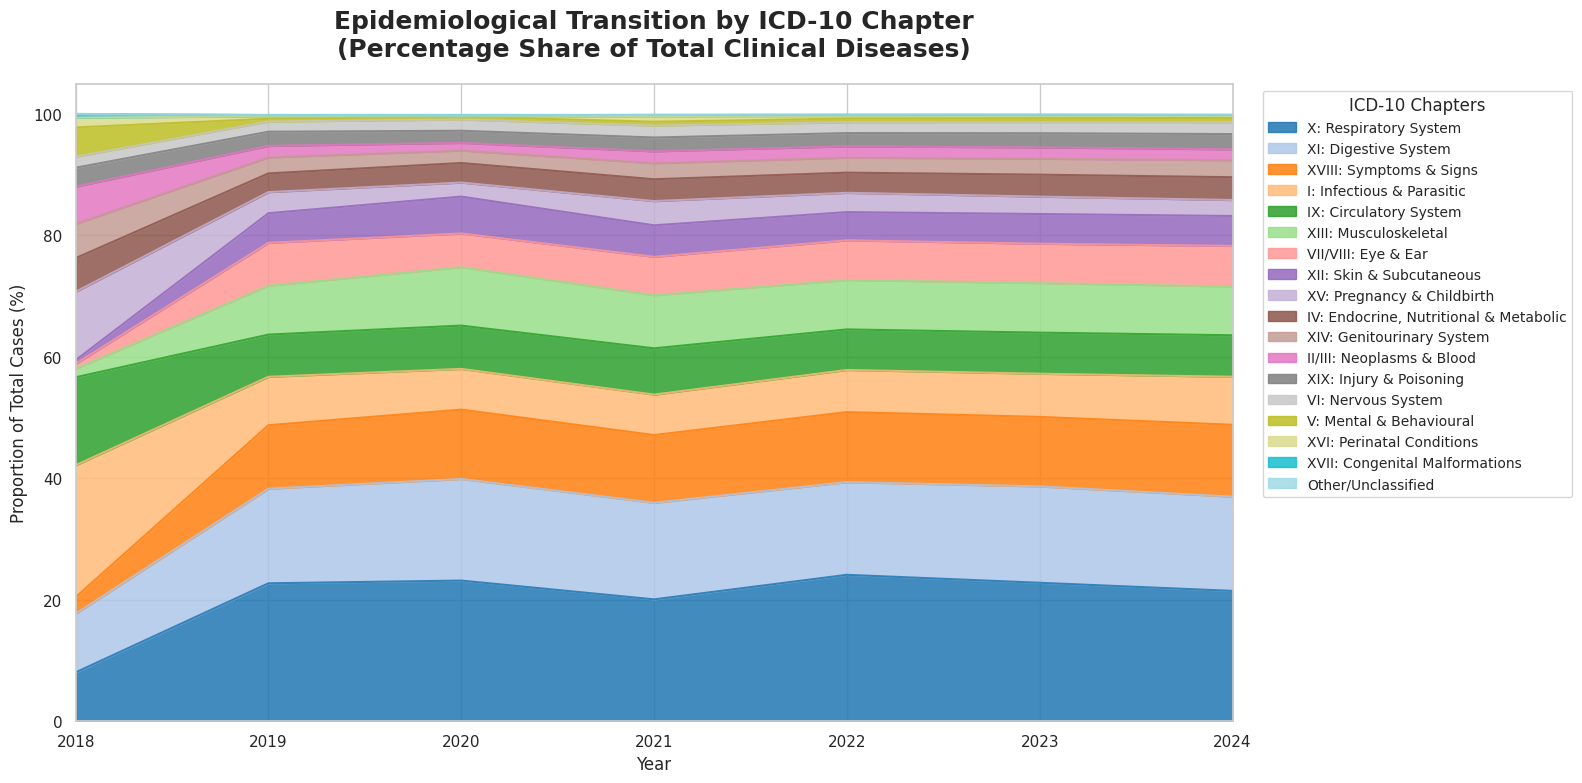


[SUCCESS] Chapter visualization saved to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Chapter_Transition_AreaChart_EN.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#@title VISUALIZATION: DISEASE BURDEN BY ICD-10 CHAPTE
print("=========================================================")
print("  VISUALIZATION: DISEASE BURDEN BY ICD-10 CHAPTER (EN)   ")
print("=========================================================\n")

# 1. filter noise (V, W, X, Y) biar murni penyakit klinis
forbidden_chars = ('V', 'W', 'X', 'Y', 'Z')
df_disease = df_non_z[~df_non_z['ICD10_CODE'].astype(str).str.startswith(forbidden_chars, na=False)].copy()

# 2. Bikin fungsi mapping huruf pertama ICD-10 ke Nama Chapter Resmi WHO
def get_icd_chapter(code):
    char = str(code)[0].upper()
    if char in ['A', 'B']: return 'I: Infectious & Parasitic'
    elif char in ['C', 'D']: return 'II/III: Neoplasms & Blood'
    elif char == 'E': return 'IV: Endocrine, Nutritional & Metabolic'
    elif char == 'F': return 'V: Mental & Behavioural'
    elif char == 'G': return 'VI: Nervous System'
    elif char == 'H': return 'VII/VIII: Eye & Ear'
    elif char == 'I': return 'IX: Circulatory System'
    elif char == 'J': return 'X: Respiratory System'
    elif char == 'K': return 'XI: Digestive System'
    elif char == 'L': return 'XII: Skin & Subcutaneous'
    elif char == 'M': return 'XIII: Musculoskeletal'
    elif char == 'N': return 'XIV: Genitourinary System'
    elif char == 'O': return 'XV: Pregnancy & Childbirth'
    elif char == 'P': return 'XVI: Perinatal Conditions'
    elif char == 'Q': return 'XVII: Congenital Malformations'
    elif char == 'R': return 'XVIII: Symptoms & Signs'
    elif char in ['S', 'T']: return 'XIX: Injury & Poisoning'
    else: return 'Other/Unclassified'

# 3. Apply mapping ke kolom baru
print("[PROCESS] Mapping ICD-10 codes to official chapters...")
df_disease['CHAPTER'] = df_disease['ICD10_CODE'].apply(get_icd_chapter)

# 4. AGREGASI: Jumlahkan porsi NEW_SHARE per Tahun dan per Chapter
df_chapter = df_disease.groupby(['TAHUN', 'CHAPTER'])['NEW_SHARE'].sum().reset_index()

# 5. Siapkan data buat visualisasi Stacked Area (Pivot)
pivot_chapter = df_chapter.pivot(index='TAHUN', columns='CHAPTER', values='NEW_SHARE').fillna(0)

# Urutkan kolom dari yang kontribusinya paling besar biar warna grafiknya rapi
top_chapters = pivot_chapter.mean().sort_values(ascending=False).index
pivot_chapter = pivot_chapter[top_chapters]

print("\n--- SUMMARY TABLE: CHAPTER SHARE (%) ---")
display(pivot_chapter.round(2))

# =====================================================================
# GRAFIK: STACKED AREA CHART
# =====================================================================
print("\n[PROCESS] Rendering Stacked Area Chart...")

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Bikin plot
pivot_chapter.plot(kind='area', stacked=True, colormap='tab20', alpha=0.85, ax=plt.gca())

# Kustomisasi label (Full English)
plt.title('Epidemiological Transition by ICD-10 Chapter\n(Percentage Share of Total Clinical Diseases)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Proportion of Total Cases (%)', fontsize=12)

# Rapikan Legend agar tidak menabrak grafik
plt.legend(title='ICD-10 Chapters', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.margins(x=0)
plt.tight_layout()

# Save ke Drive
path_plot = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Chapter_Transition_AreaChart_EN.png'
plt.savefig(path_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Chapter visualization saved to: {path_plot}")

  VISUALIZATION OF DISEASE PROPORTION TRENDS             

[INFO] 2018 data, non-disease codes, and NANs successfully cleaned.
[STAT] Found 7 unique diseases that EVER entered the Monthly Top 5.
[STAT] Found 12 unique diseases that EVER entered the Monthly Top 10.

--- RENDERING CHARTS FOR MONTHLY TOP 5 ---


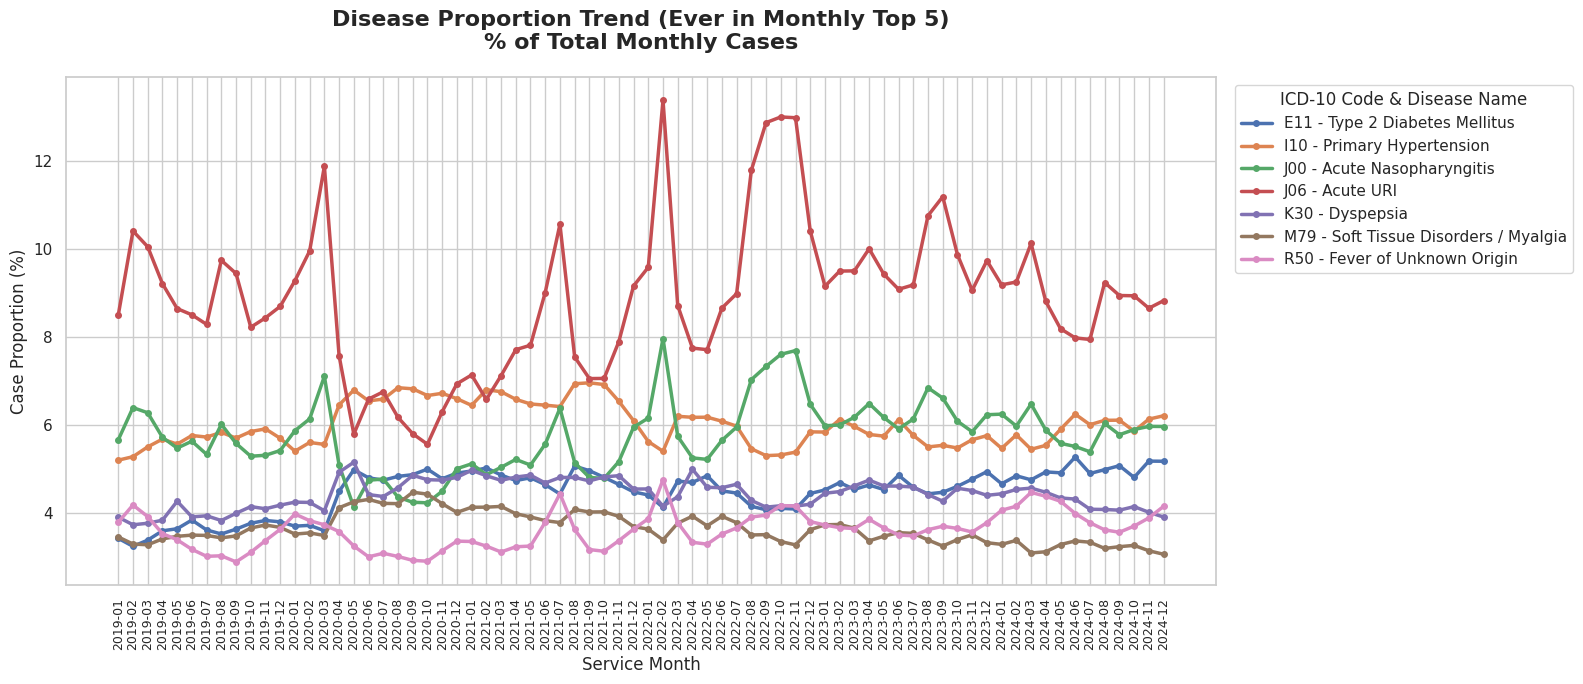

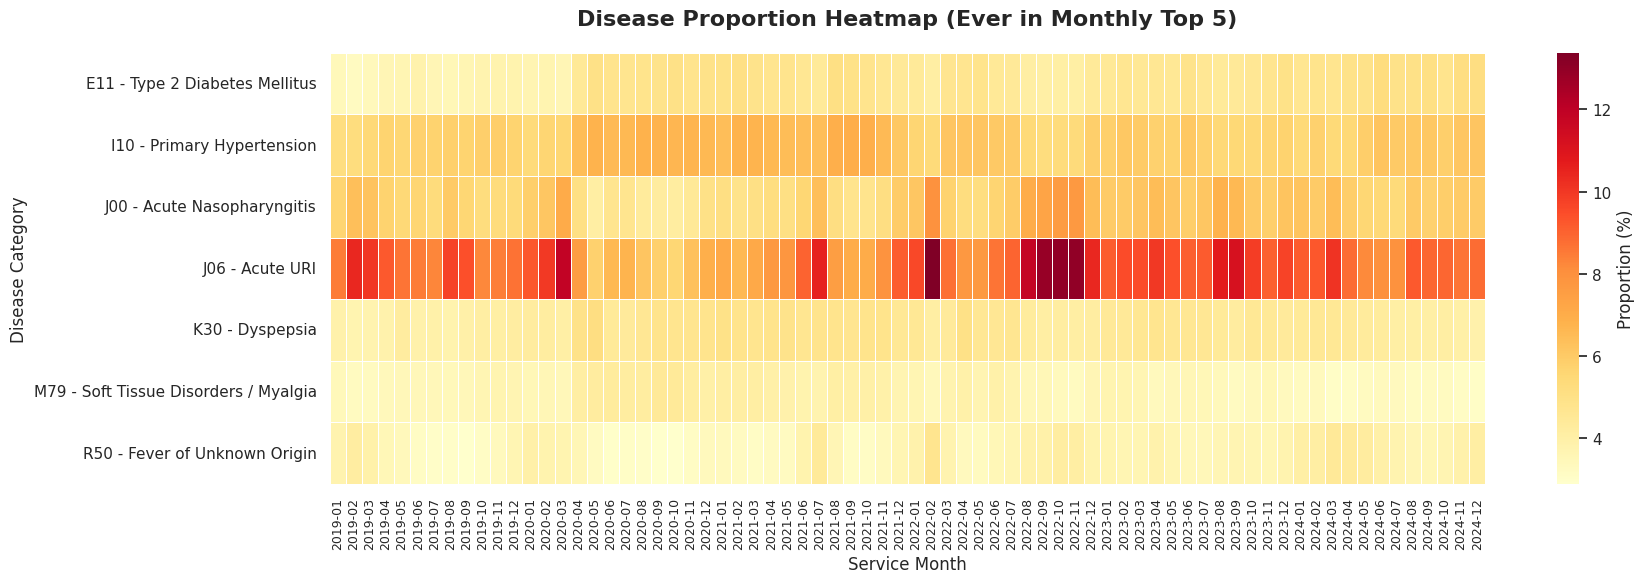

-> [SUCCESS] Saved Top5 PNG charts to Google Drive.

--- RENDERING CHARTS FOR MONTHLY TOP 10 ---


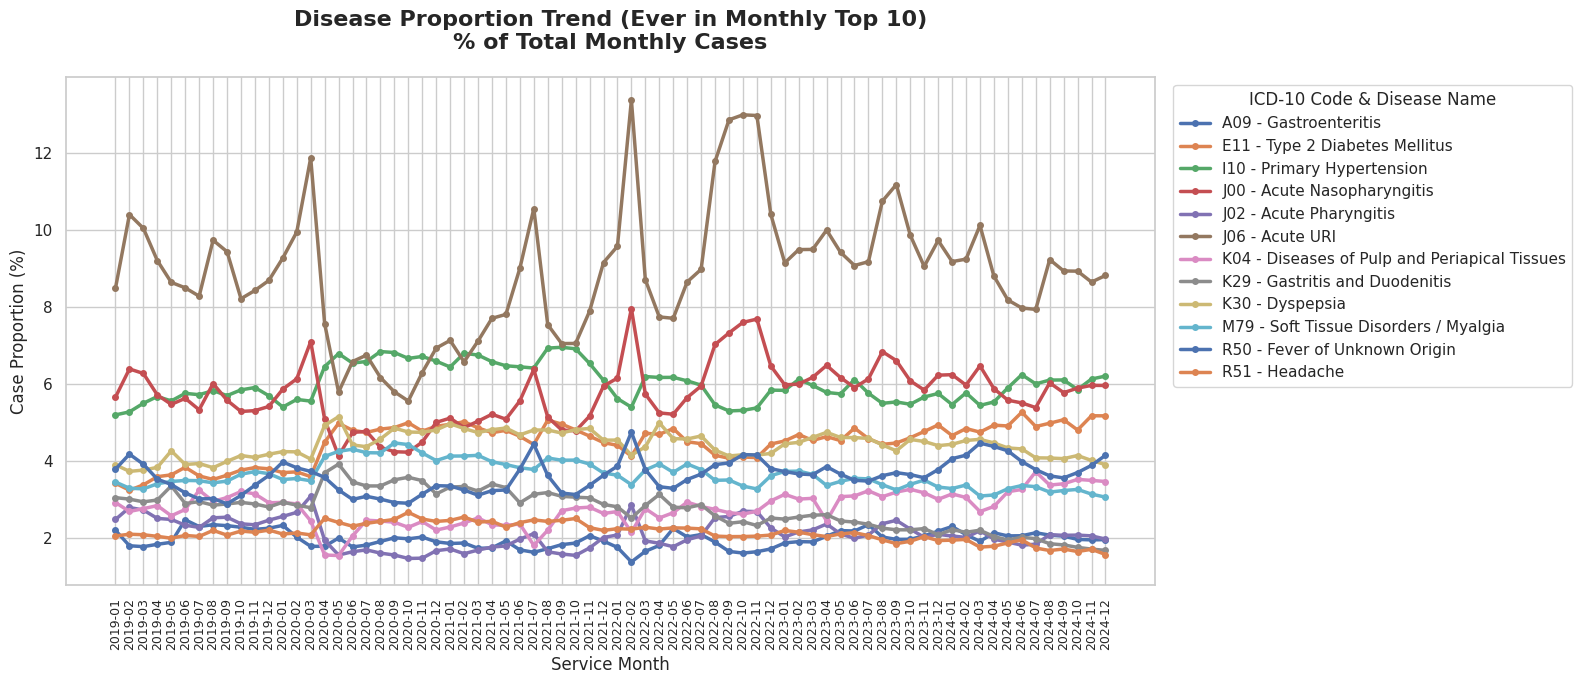

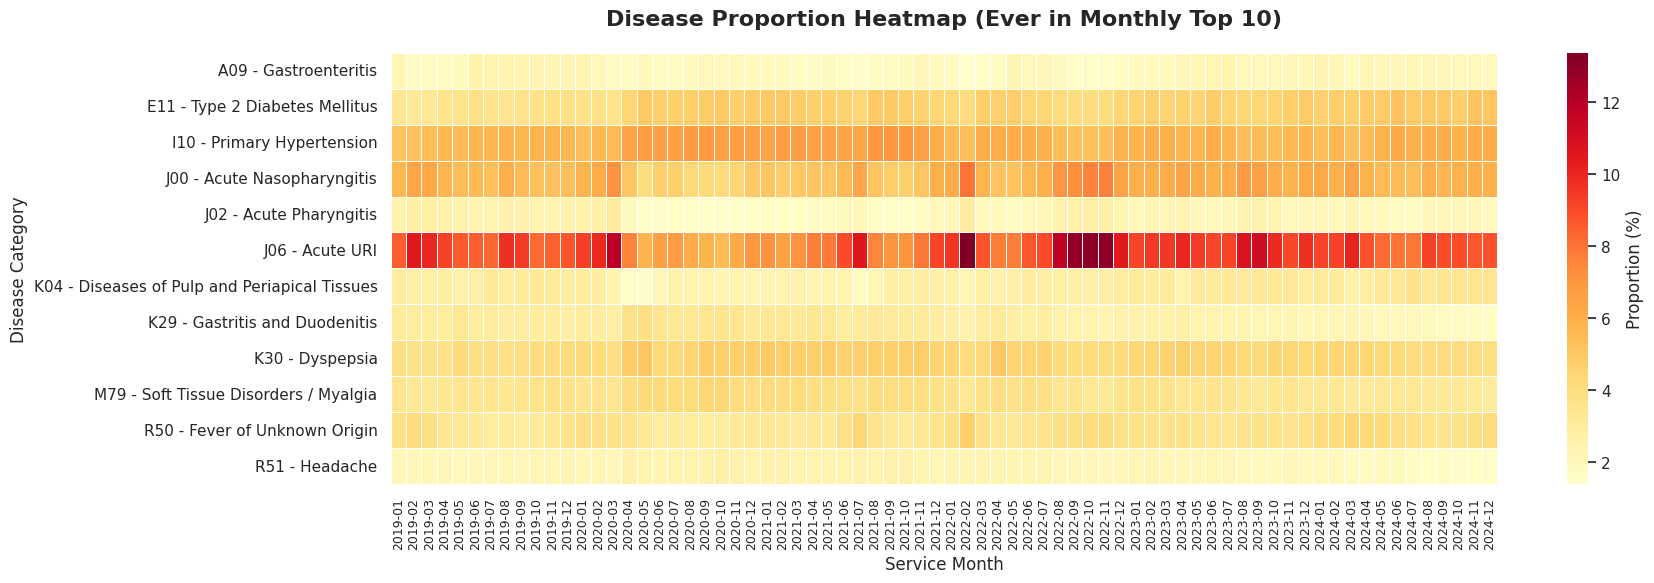

-> [SUCCESS] Saved Top10 PNG charts to Google Drive.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
#@title VISUALIZATION OF DISEASE PROPORTION TREND
print("=========================================================")
print("  VISUALIZATION OF DISEASE PROPORTION TRENDS             ")
print("=========================================================\n")

# Dictionary for English ICD-10 names (UPDATED WITH J02)
icd10_dict_en = {
    'I10': 'Primary Hypertension', 'E11': 'Type 2 Diabetes Mellitus', 'K30': 'Dyspepsia',
    'A09': 'Gastroenteritis', 'J00': 'Acute Nasopharyngitis',
    'J02': 'Acute Pharyngitis', 'J06': 'Acute URI', 'F20': 'Schizophrenia',
    'I50': 'Heart Failure', 'I63': 'Cerebral Infarction (Stroke)',
    'N18': 'Chronic Kidney Disease', 'A01': 'Typhoid Fever',
    'A91': 'Dengue Haemorrhagic Fever', 'J18': 'Pneumonia', 'J44': 'COPD', 'A16': 'Pulmonary TB',
    'M79': 'Soft Tissue Disorders / Myalgia', 'R50': 'Fever of Unknown Origin',
    'R51': 'Headache', 'K29': 'Gastritis and Duodenitis',
    'K04': 'Diseases of Pulp and Periapical Tissues'
}

# 1. Read monthly data
path_data = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Tren_Penyakit_Bulanan.csv'
df = pd.read_csv(path_data)

# 2. CLEANING: Ensure string, strip spaces, uppercase
df['ICD10_3D'] = df['ICD10_3D'].astype(str).str.strip().str.upper()

# Banish 'NAN' and the likes
df = df[~df['ICD10_3D'].isin(['NAN', 'NONE', '', 'NAT', 'NULL'])]

# 3. FILTER YEAR: Drop 2018
df['TAHUN'] = df['BULAN_KUNJUNGAN'].str[:4]
df = df[df['TAHUN'] != '2018']

# 4. FILTER NOISE: Drop Z, V, W, X, Y & O80
huruf_terlarang = ('Z', 'V', 'W', 'X', 'Y')
df = df[~df['ICD10_3D'].str.startswith(huruf_terlarang, na=False)]
df = df[df['ICD10_3D'] != 'O80']

print(f"[INFO] 2018 data, non-disease codes, and NANs successfully cleaned.")

# =====================================================================
# INJECT OFFICIAL DISEASE NAMES
# =====================================================================
# Gabungkan kode dengan nama penyakit, jika tidak ada di dict maka 'Other Diseases'
df['DISPLAY_NAME'] = df['ICD10_3D'] + ' - ' + df['ICD10_3D'].map(icd10_dict_en).fillna('Other Diseases')

# =====================================================================
# CALCULATE PERCENTAGE PROPORTION & MONTHLY RANKING
# =====================================================================
# Calculate 'valid' total cases per month as denominator
total_per_bulan = df.groupby('BULAN_KUNJUNGAN')['JUMLAH_KASUS'].sum().reset_index(name='TOTAL_KASUS_BULAN')
df = pd.merge(df, total_per_bulan, on='BULAN_KUNJUNGAN')

# Case Proportion (%)
df['PROPORSI_PERSEN'] = (df['JUMLAH_KASUS'] / df['TOTAL_KASUS_BULAN']) * 100

# Create Monthly Ranking (Rank 1 = Largest Proportion)
df['RANK_BULANAN'] = df.groupby('BULAN_KUNJUNGAN')['PROPORSI_PERSEN'].rank(method='dense', ascending=False)

# Collect diseases that EVER entered Top 5 or Top 10
ever_top_5_icd = df[df['RANK_BULANAN'] <= 5]['DISPLAY_NAME'].unique()
ever_top_10_icd = df[df['RANK_BULANAN'] <= 10]['DISPLAY_NAME'].unique()

print(f"[STAT] Found {len(ever_top_5_icd)} unique diseases that EVER entered the Monthly Top 5.")
print(f"[STAT] Found {len(ever_top_10_icd)} unique diseases that EVER entered the Monthly Top 10.")

# =====================================================================
# PLOTTING FUNCTION
# =====================================================================
def plot_trend(icd_list, title_suffix, save_suffix):
    df_plot = df[df['DISPLAY_NAME'].isin(icd_list)].copy()

    # --- LINE CHART ---
    pivot_line = df_plot.pivot(index='BULAN_KUNJUNGAN', columns='DISPLAY_NAME', values='PROPORSI_PERSEN').fillna(0)
    plt.figure(figsize=(16, 7))
    sns.set_theme(style="whitegrid")
    for icd in pivot_line.columns:
        plt.plot(pivot_line.index, pivot_line[icd], linewidth=2.5, marker='o', markersize=4, label=icd)

    plt.title(f'Disease Proportion Trend ({title_suffix})\n% of Total Monthly Cases', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Service Month', fontsize=12)
    plt.ylabel('Case Proportion (%)', fontsize=12)
    plt.xticks(rotation=90, fontsize=9)
    plt.legend(title='ICD-10 Code & Disease Name', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()

    # Save Line Chart to Drive
    path_line = f'/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Trend_LineChart_{save_suffix}_EN.png'
    plt.savefig(path_line, dpi=300, bbox_inches='tight')
    plt.show()

    # --- HEATMAP ---
    pivot_heat = df_plot.pivot(index='DISPLAY_NAME', columns='BULAN_KUNJUNGAN', values='PROPORSI_PERSEN').fillna(0)

    # Auto-adjust heatmap height based on number of diseases
    plt.figure(figsize=(18, max(6, len(icd_list)*0.4)))
    sns.heatmap(pivot_heat, cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Proportion (%)'})

    plt.title(f'Disease Proportion Heatmap ({title_suffix})', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Service Month', fontsize=12)
    plt.ylabel('Disease Category', fontsize=12)
    plt.xticks(rotation=90, fontsize=9)
    plt.tight_layout()

    # Save Heatmap to Drive
    path_heat = f'/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Trend_Heatmap_{save_suffix}_EN.png'
    plt.savefig(path_heat, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"-> [SUCCESS] Saved {save_suffix} PNG charts to Google Drive.")

# =====================================================================
# EXECUTE GRAPH RENDERING
# =====================================================================
print("\n--- RENDERING CHARTS FOR MONTHLY TOP 5 ---")
plot_trend(ever_top_5_icd, "Ever in Monthly Top 5", "Top5")

print("\n--- RENDERING CHARTS FOR MONTHLY TOP 10 ---")
plot_trend(ever_top_10_icd, "Ever in Monthly Top 10", "Top10")

In [ ]:
import pandas as pd
from IPython.display import display
#@title MATRIKS HASIL FORECASTING PROPHET
print("=========================================================")
print("  MATRIKS HASIL FORECASTING PROPHET (2025 - 2026)        ")
print("=========================================================\n")

# 1. Load data hasil forecast dari skrip Prophet sebelumnya
path_forecast = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Forecast_Proporsi_Prophet_24Bulan.csv'
df_forecast = pd.read_csv(path_forecast)

# Dictionary nama penyakit resmi (Bahasa Inggris)
icd10_dict_en = {
    'I10': 'Primary Hypertension', 'E11': 'Type 2 Diabetes Mellitus', 'K30': 'Dyspepsia',
    'A09': 'Gastroenteritis', 'J00': 'Acute Nasopharyngitis',
    'J02': 'Acute Pharyngitis', 'J06': 'Acute URI', 'F20': 'Schizophrenia',
    'I50': 'Heart Failure', 'I63': 'Cerebral Infarction (Stroke)',
    'N18': 'Chronic Kidney Disease', 'A01': 'Typhoid Fever',
    'A91': 'Dengue Haemorrhagic Fever', 'J18': 'Pneumonia', 'J44': 'COPD', 'A16': 'Pulmonary TB',
    'M79': 'Soft Tissue Disorders / Myalgia', 'R50': 'Fever of Unknown Origin',
    'R51': 'Headache', 'K29': 'Gastritis and Duodenitis',
    'K04': 'Diseases of Pulp and Periapical Tissues'
}

# Gabungkan kode dengan nama penyakit
df_forecast['DISPLAY_NAME'] = df_forecast['ICD10_3D'] + ' - ' + df_forecast['ICD10_3D'].map(icd10_dict_en).fillna('Other Diseases')

# Format kolom tanggal jadi lebih ramah baca (contoh: Jan-2025)
df_forecast['ds'] = pd.to_datetime(df_forecast['ds'])
df_forecast['BULAN_TAHUN'] = df_forecast['ds'].dt.strftime('%b-%Y')

# 2. CORE LOGIC: Bikin Pivot Table (Matriks) untuk nilai yhat (Proyeksi Base/Utama)
matriks_forecast = df_forecast.pivot(index='DISPLAY_NAME', columns='BULAN_TAHUN', values='yhat')

# Urutkan kolom secara kronologis waktu
waktu_urut = df_forecast.sort_values('ds')['BULAN_TAHUN'].unique()
matriks_forecast = matriks_forecast[waktu_urut].round(2) # Bulatkan 2 angka desimal biar rapi

# Tambahkan kolom Rata-Rata
matriks_forecast['Average Forecast (%)'] = matriks_forecast.mean(axis=1).round(2)
matriks_forecast = matriks_forecast.sort_values(by='Average Forecast (%)', ascending=False)

print("--- MATRIX OF PROJECTED DISEASE PROPORTION (%) | 24 MONTHS ---")
display(matriks_forecast)

# 3. Save Matriks ke format CSV
path_matriks_out = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Matriks_Tabel_Forecast_2025_2026.csv'
matriks_forecast.to_csv(path_matriks_out)

print(f"\n[SUCCESS] Matrix table saved securely to: {path_matriks_out}")

  MATRIKS HASIL FORECASTING PROPHET (2025 - 2026)        

--- MATRIX OF PROJECTED DISEASE PROPORTION (%) | 24 MONTHS ---


BULAN_TAHUN,Jan-2019,Feb-2019,Mar-2019,Apr-2019,May-2019,Jun-2019,Jul-2019,Aug-2019,Sep-2019,Oct-2019,...,Apr-2026,May-2026,Jun-2026,Jul-2026,Aug-2026,Sep-2026,Oct-2026,Nov-2026,Dec-2026,Average Forecast (%)
DISPLAY_NAME,,,,,,,,,,,,,,,,,,,,,
J06 - Acute URI,8.18,9.23,8.38,8.35,7.76,7.49,7.33,8.76,8.97,8.10,...,9.77,9.20,9.36,9.50,10.37,10.45,9.87,9.96,10.06,9.12
I10 - Primary Hypertension,5.11,5.31,5.64,5.61,5.59,5.93,5.88,5.82,5.84,5.94,...,5.89,5.91,6.06,5.94,5.92,5.88,5.85,5.88,5.84,5.97
J00 - Acute Nasopharyngitis,5.43,5.80,5.49,5.38,5.07,4.97,4.97,5.62,5.40,5.20,...,6.42,6.10,6.22,6.32,6.70,6.51,6.39,6.49,6.58,5.92
E11 - Type 2 Diabetes Mellitus,3.22,3.25,3.51,3.58,3.64,3.82,3.71,3.66,3.75,3.91,...,5.50,5.56,5.63,5.44,5.43,5.45,5.49,5.53,5.60,4.69
K30 - Dyspepsia,3.78,3.74,3.82,4.04,4.10,4.03,4.12,3.94,3.92,4.16,...,4.23,4.22,4.02,4.01,3.87,3.83,3.94,3.89,3.83,4.33
R50 - Fever of Unknown Origin,3.50,3.67,3.43,3.33,3.23,3.21,3.19,3.21,3.10,3.17,...,4.20,4.07,4.05,4.10,4.03,3.93,4.01,4.11,4.24,3.73
M79 - Soft Tissue Disorders / Myalgia,3.27,3.26,3.40,3.38,3.44,3.61,3.64,3.58,3.57,3.69,...,2.79,2.79,2.85,2.80,2.70,2.68,2.71,2.67,2.60,3.45
K04 - Diseases of Pulp and Periapical Tissues,2.97,2.78,2.75,2.49,2.61,2.70,2.82,2.69,2.79,2.87,...,3.37,3.54,3.71,3.86,3.79,3.92,4.00,4.01,3.92,2.99
K29 - Gastritis and Duodenitis,2.88,2.84,3.01,3.11,3.14,3.00,3.11,3.02,3.01,3.06,...,1.47,1.44,1.22,1.24,1.12,1.07,1.07,1.01,0.91,2.41



[SUCCESS] Matrix table saved securely to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Matriks_Tabel_Forecast_2025_2026.csv


  PROPHET FORECASTING: DISEASE PROPORTION (2 YEARS)      

[INFO] Found 12 unique diseases to forecast.
[PROCESS] Starting model training and forecasting for each disease...


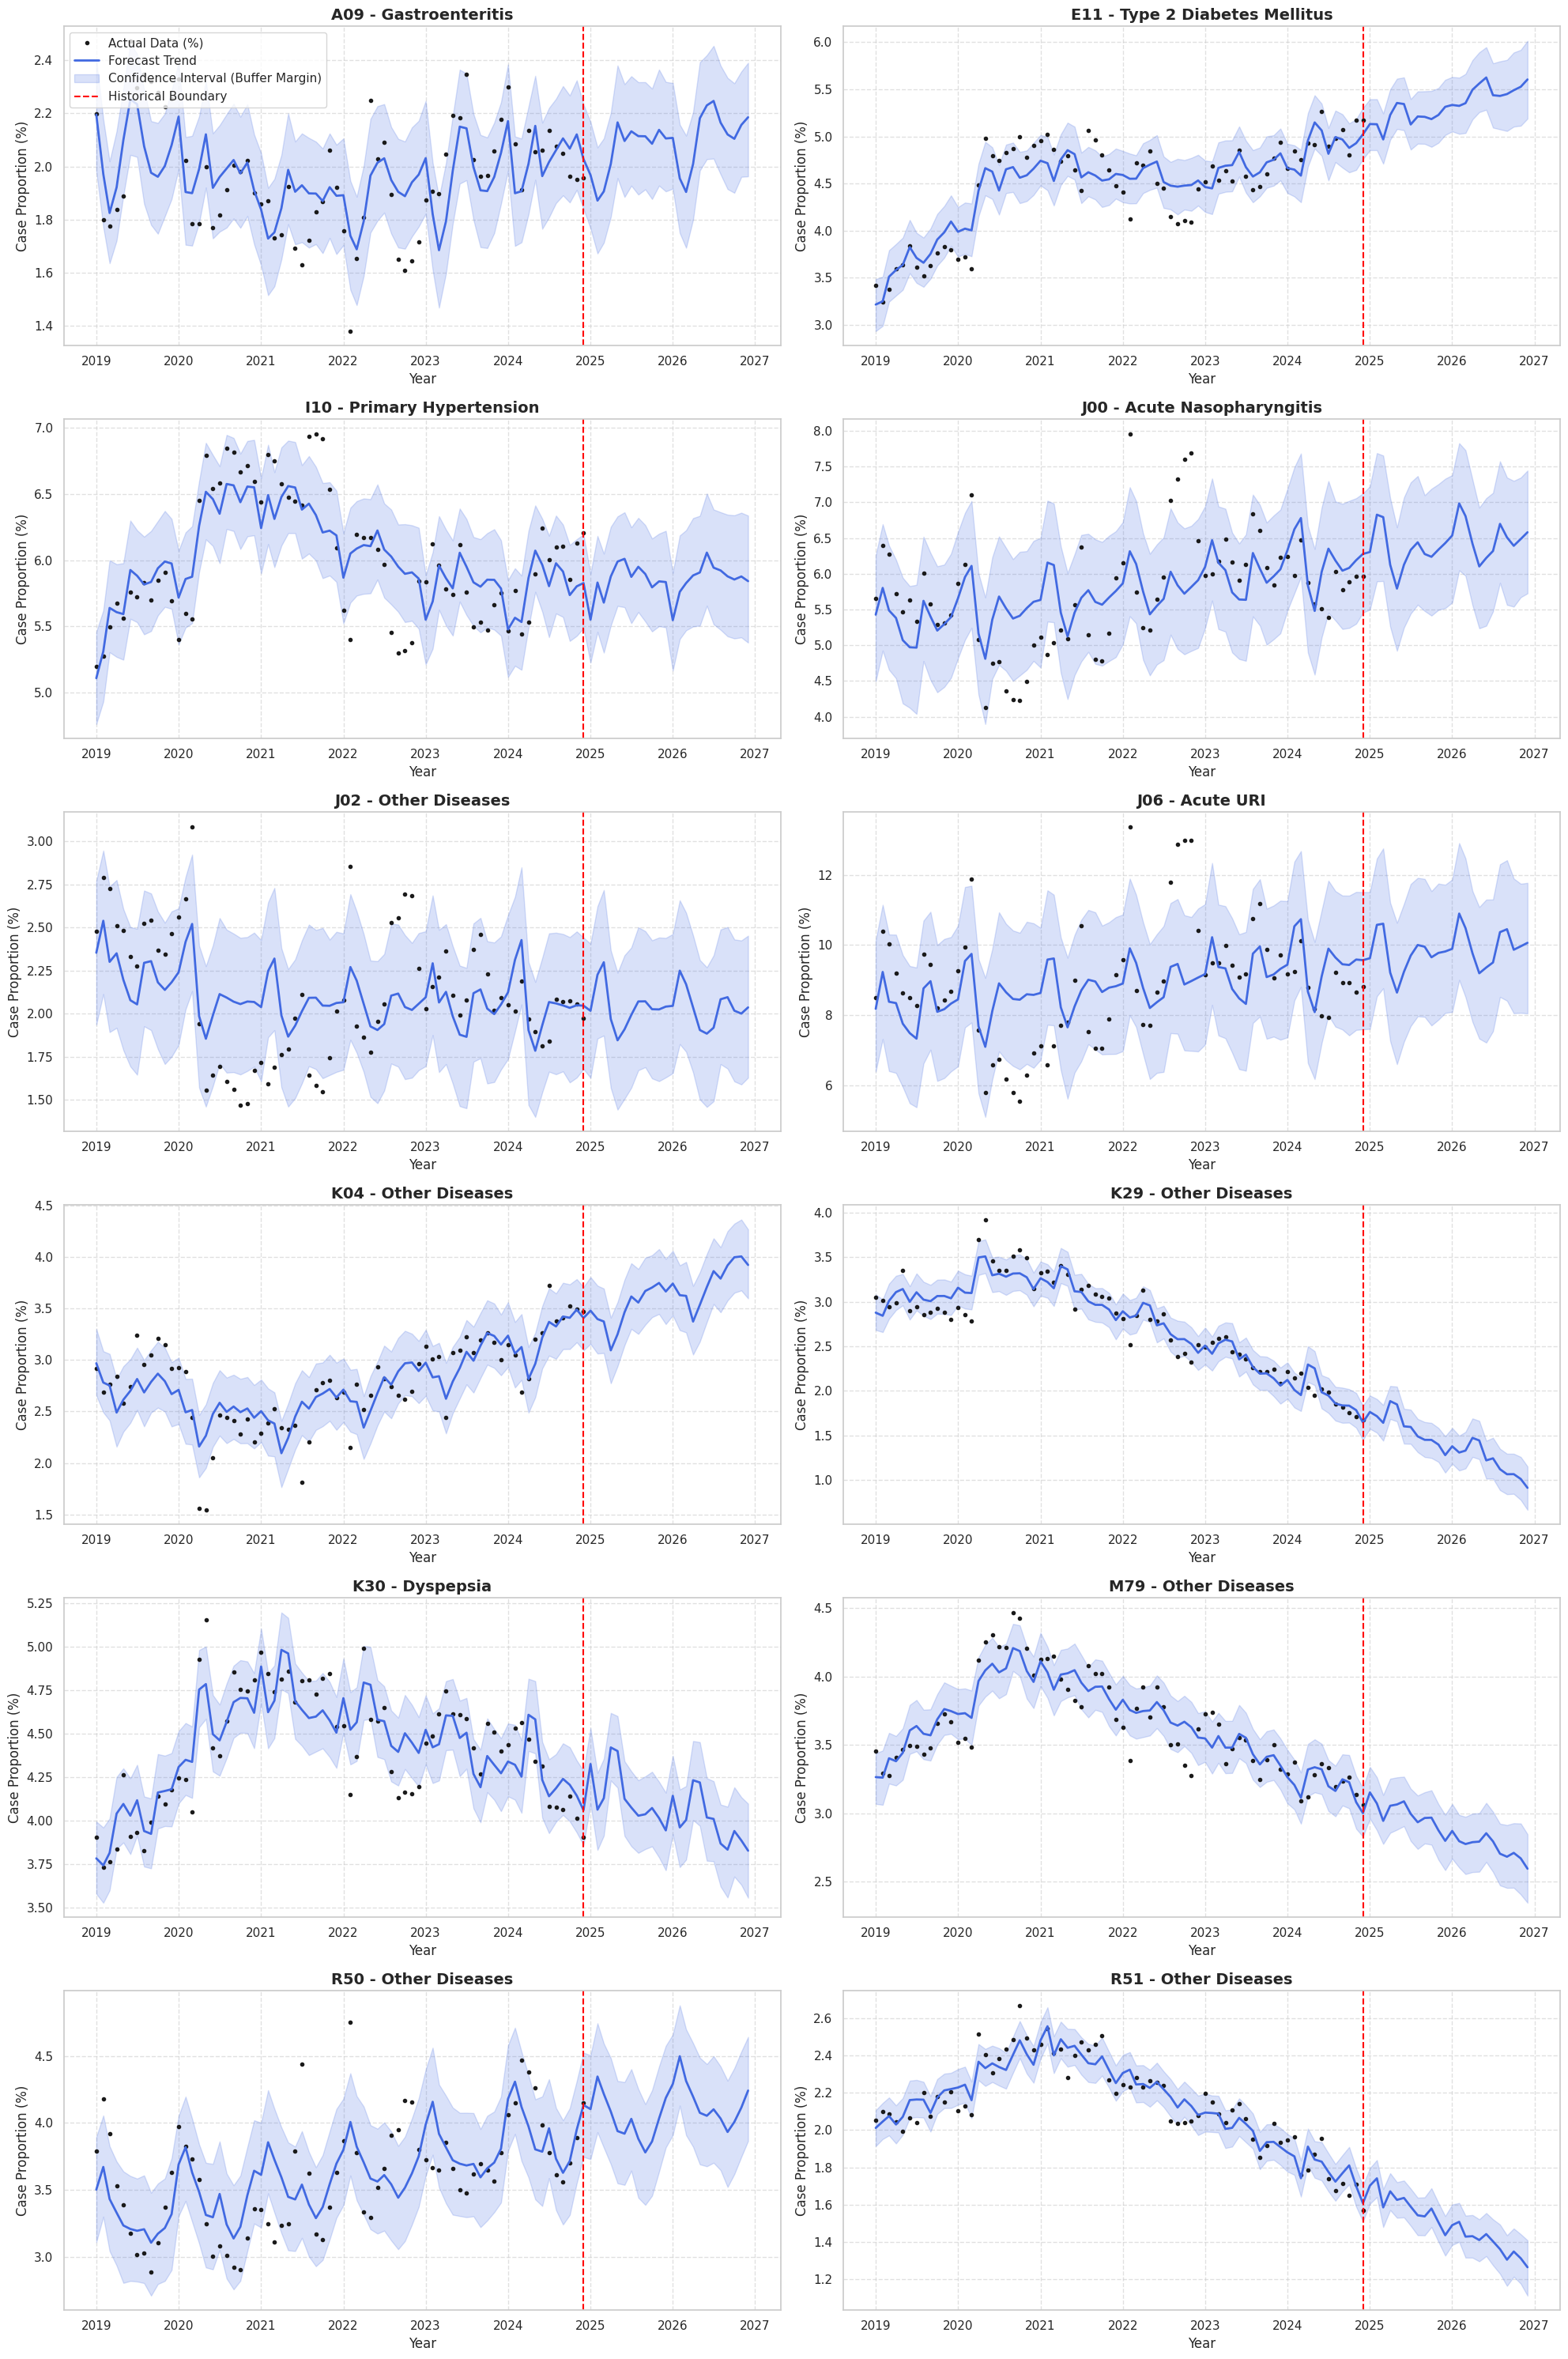


[SUCCESS] 24-month forecasting completed.
-> Forecast data saved to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Forecast_Proporsi_Prophet_24Bulan.csv
-> Forecast plot saved to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Prophet_Forecast_Grid_EN.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import warnings
import math
import os
#@title PROPHET FORECASTING: DISEASE PROPORTIO
warnings.filterwarnings('ignore')

print("=========================================================")
print("  PROPHET FORECASTING: DISEASE PROPORTION (2 YEARS)      ")
print("=========================================================\n")

# Dictionary
icd10_dict_en = {
    'I10': 'Primary Hypertension', 'E11': 'Type 2 Diabetes Mellitus', 'K30': 'Dyspepsia',
    'A09': 'Gastroenteritis', 'J00': 'Acute Nasopharyngitis',
    'J06': 'Acute URI', 'F20': 'Schizophrenia', 'I50': 'Heart Failure',
    'I63': 'Cerebral Infarction (Stroke)', 'N18': 'Chronic Kidney Disease', 'A01': 'Typhoid Fever',
    'A91': 'Dengue Haemorrhagic Fever', 'J18': 'Pneumonia', 'J44': 'COPD', 'A16': 'Pulmonary TB'
}

# 1. Load processed data
path_tabel = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Matriks_Proporsi_Top10.csv'
df_pivot = pd.read_csv(path_tabel, index_col='ICD10_3D')

# Transpose data so Months become rows
df_ts = df_pivot.T
df_ts.index.name = 'ds'
df_ts = df_ts.reset_index()
df_ts['ds'] = pd.to_datetime(df_ts['ds'] + '-01')

all_forecasts = pd.DataFrame()

# 2. CREATE DYNAMIC CANVAS
total_penyakit = len(df_pivot.index)
print(f"[INFO] Found {total_penyakit} unique diseases to forecast.")

kolom = 2
baris = math.ceil(total_penyakit / kolom)

fig, axes = plt.subplots(baris, kolom, figsize=(20, 5 * baris))
axes = axes.flatten() # Flatten 2D array to 1D for easier looping

print("[PROCESS] Starting model training and forecasting for each disease...")

for i, icd in enumerate(df_pivot.index):
    df_prophet = df_ts[['ds', icd]].rename(columns={icd: 'y'})

    m = Prophet(seasonality_mode='additive',
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False)
    m.fit(df_prophet)

    future = m.make_future_dataframe(periods=24, freq='MS')
    forecast = m.predict(future)

    # Prevent negative predictions
    forecast['yhat'] = forecast['yhat'].clip(lower=0)
    forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
    forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

    temp_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    temp_forecast['ICD10_3D'] = icd
    all_forecasts = pd.concat([all_forecasts, temp_forecast])

    ax = axes[i]
    ax.plot(df_prophet['ds'], df_prophet['y'], 'ko', markersize=3, label='Actual Data (%)')
    ax.plot(forecast['ds'], forecast['yhat'], color='royalblue', linewidth=2, label='Forecast Trend')
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='royalblue', alpha=0.2, label='Confidence Interval (Buffer Margin)')

    # Ambil nama penyakit dari dictionary, default ke 'Other Diseases' kalau gak ketemu
    disease_name = icd10_dict_en.get(icd, 'Other Diseases')

    # Format Judul Baru: Kode - Nama Penyakit
    ax.set_title(f'{icd} - {disease_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Case Proportion (%)')
    ax.grid(True, linestyle='--', alpha=0.6)

    last_date = df_prophet['ds'].max()
    ax.axvline(x=last_date, color='red', linestyle='--', linewidth=1.5, label='Historical Boundary')

    if i == 0:
        ax.legend(loc='upper left')

# Remove empty subplots if the number of diseases is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save plot to drive
path_plot = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Prophet_Forecast_Grid_EN.png'
plt.savefig(path_plot, dpi=300, bbox_inches='tight')
plt.show()

path_out_forecast = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Forecast_Proporsi_Prophet_24Bulan.csv'
all_forecasts.to_csv(path_out_forecast, index=False)

print(f"\n[SUCCESS] 24-month forecasting completed.")
print(f"-> Forecast data saved to: {path_out_forecast}")
print(f"-> Forecast plot saved to: {path_plot}")

  VISUALIZATION: EPIDEMIOLOGICAL BURDEN (ENGLISH VERSION)  

--- TOP 10 DISEASE PROPORTION TABLE ---


,2019,2020,2021,2022,2023,2024,Average (%)
ICD10_3D,,,,,,,
J06,20.05,18.02,17.39,23.11,21.87,20.58,20.17
J00,13.33,12.72,12.06,15.31,14.94,14.67,13.84
K30,10.03,10.10,11.32,11.28,11.96,11.45,11.02
R50,9.32,8.59,9.08,10.60,10.19,11.20,9.83
M79,8.42,9.47,9.17,8.95,9.00,8.44,8.91
I10,7.24,7.50,7.73,6.85,7.03,7.13,7.25
K29,7.50,8.11,7.50,6.76,6.31,5.35,6.92
J02,6.79,5.55,4.73,6.31,6.23,5.93,5.92
A09,6.39,5.16,5.26,5.57,6.58,6.55,5.92


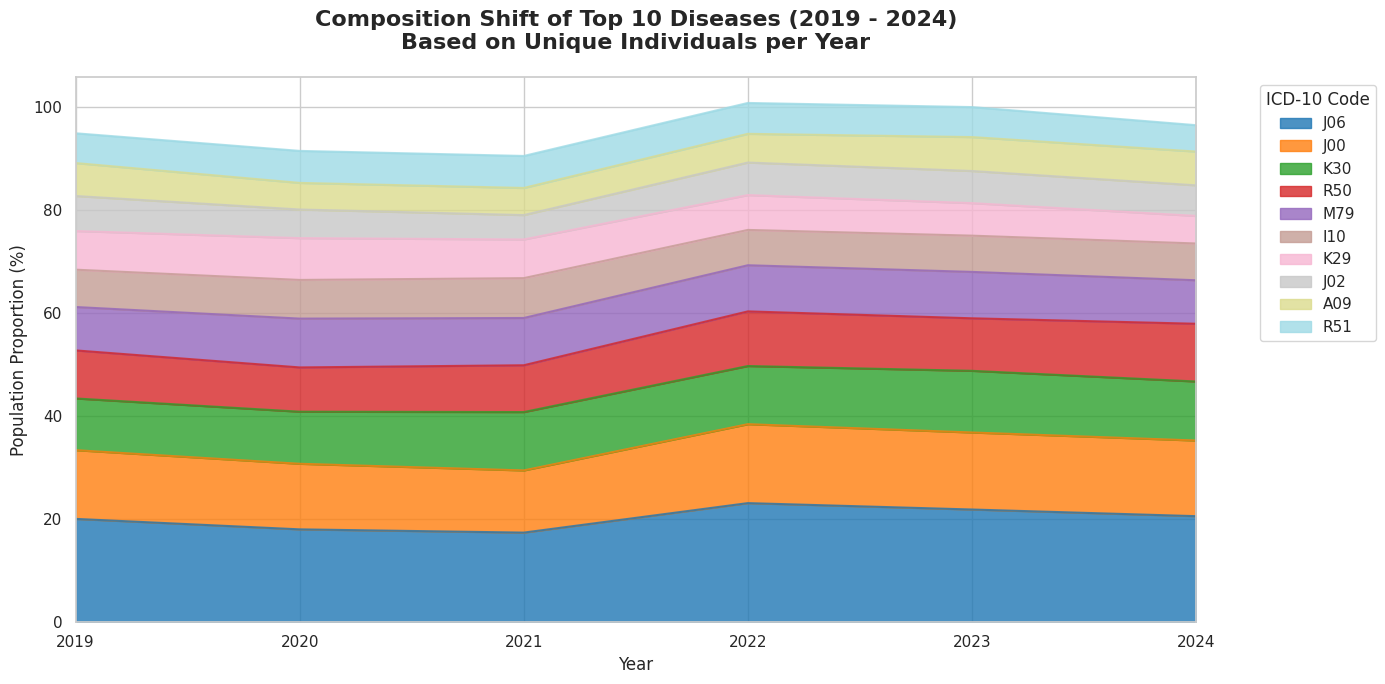


[SUCCESS] English Stacked Area Chart exported to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Stacked_Area_Top10_EN.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
#@title VISUALIZATION: EPIDEMIOLOGICAL BURDEN
print("=========================================================")
print("  VISUALIZATION: EPIDEMIOLOGICAL BURDEN (ENGLISH VERSION)  ")
print("=========================================================\n")

# 1. Load tabel proporsi individu yang sudah diekstrak sebelumnya
path_in = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Tabel_Individu_Top10.csv'
pivot_tabel = pd.read_csv(path_in, index_col='ICD10_3D')

# Ubah nama kolom 'Rata_Rata (%)' ke bahasa Inggris buat di tabel output
if 'Rata_Rata (%)' in pivot_tabel.columns:
    pivot_tabel = pivot_tabel.rename(columns={'Rata_Rata (%)': 'Average (%)'})

print("--- TOP 10 DISEASE PROPORTION TABLE ---")
display(pivot_tabel)

# =====================================================================
# GRAFIK: 100% STACKED AREA CHART (FULL ENGLISH)
# =====================================================================
# 2. Siapkan data untuk plotting (Drop kolom rata-rata agar tidak ikut ke-plot)
if 'Average (%)' in pivot_tabel.columns:
    pivot_plot = pivot_tabel.drop(columns=['Average (%)']).T
else:
    pivot_plot = pivot_tabel.T

# 3. Eksekusi Visualisasi
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plot stacked area
pivot_plot.plot(kind='area', stacked=True, colormap='tab20', alpha=0.8, ax=plt.gca())

# TRANSLATE TITLE & LABELS
plt.title('Composition Shift of Top 10 Diseases (2019 - 2024)\nBased on Unique Individuals per Year',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population Proportion (%)', fontsize=12)
plt.legend(title='ICD-10 Code', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.margins(x=0)
plt.tight_layout()

# Save Plot ke format PNG High-Res
path_plot = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Stacked_Area_Top10_EN.png'
plt.savefig(path_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Stacked Area Chart exported to: {path_plot}")

  VISUALIZATION OF DRUG DEMAND FLUCTUATION (2025-2026)   



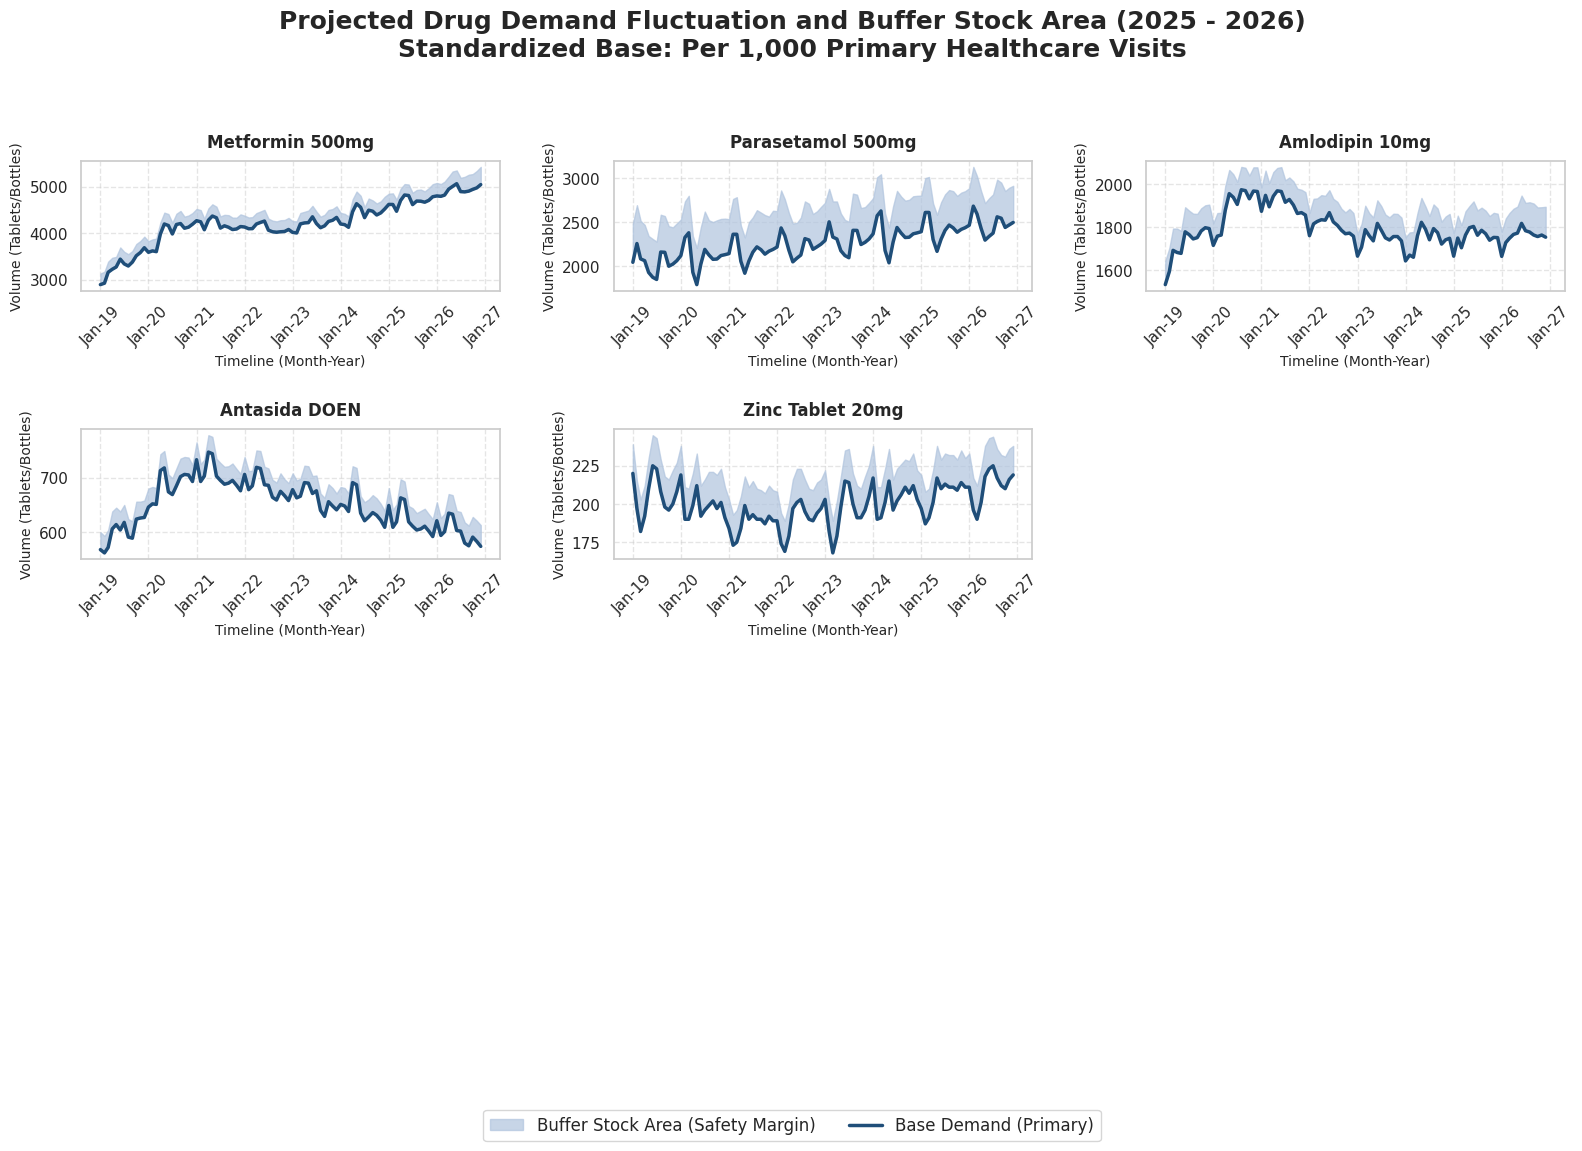


[SUCCESS] HD English fluctuation chart exported to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Trend_Fluktuasi_Obat_EN.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
#@title VISUALIZATION OF DRUG DEMAND FLUCTUATION (2025-2026)
print("=========================================================")
print("  VISUALIZATION OF DRUG DEMAND FLUCTUATION (2025-2026)   ")
print("=========================================================\n")

# 1. Load Data RKO
path_rko = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Master_Rencana_Kebutuhan_Obat_2025_2026.csv'
df_rko = pd.read_csv(path_rko)
df_rko['ds'] = pd.to_datetime(df_rko['ds'])

# 2. Aggregate per month and per drug
df_trend = df_rko.groupby(['ds', 'Obat_Utama'])[['KEBUTUHAN_OBAT_UTAMA', 'BUFFER_STOCK_AMAN']].sum().reset_index()

# Sort by highest volume for better layout
order_obat = df_trend.groupby('Obat_Utama')['BUFFER_STOCK_AMAN'].max().sort_values(ascending=False).index

# 3. Canvas setup (Grid 4x3)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12), sharex=False)
axes = axes.flatten()

# Corporate/Academic color palette
color_main = '#1f4e79'
color_buffer = '#b0c4de'

for i, obat in enumerate(order_obat):
    if i < 12:
        ax = axes[i]
        data = df_trend[df_trend['Obat_Utama'] == obat]

        # Buffer Stock Area (Safety Margin)
        ax.fill_between(data['ds'], data['KEBUTUHAN_OBAT_UTAMA'], data['BUFFER_STOCK_AMAN'],
                        color=color_buffer, alpha=0.7, label='Buffer Stock Area (Safety Margin)')

        # Main Demand Trend Line
        ax.plot(data['ds'], data['KEBUTUHAN_OBAT_UTAMA'], color=color_main, linewidth=2.5, label='Base Demand (Primary)')

        ax.set_title(obat, fontsize=12, fontweight='bold', pad=10)
        ax.grid(True, linestyle='--', alpha=0.5)

        # COMPLETE AXIS LABELS
        ax.set_ylabel('Volume (Tablets/Bottles)', fontsize=10)
        ax.set_xlabel('Timeline (Month-Year)', fontsize=10)

        # Date format for X-axis (e.g., Jan-25)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))

        # Put ticks at a reasonable angle so they don't overlap
        ax.tick_params(axis='x', rotation=45)

# Hide empty subplots if drugs are less than 12
for j in range(i + 1, 12):
    axes[j].set_visible(False)

# 4. PENYESUAIAN POSISI LEGEND & TITLE YANG LEBIH RAPAT
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.03))

# Baris ini udah diamankan dari IndentationError
judul_grafik = 'Projected Drug Demand Fluctuation and Buffer Stock Area (2025 - 2026)\nStandardized Base: Per 1,000 Primary Healthcare Visits'
fig.suptitle(judul_grafik, fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.06, 1, 0.95], h_pad=2.0, w_pad=2.0)

# Save Plot
path_plot = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Trend_Fluktuasi_Obat_EN.png'
plt.savefig(path_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] fluctuation chart exported to: {path_plot}")

  VISUALIZATION: DISEASE BURDEN BY ICD-10 CHAPTER (EN)   

[PROCESS] Recalculating denominator and new share percentages...
[PROCESS] Mapping ICD-10 codes to official chapters...

--- SUMMARY TABLE: CHAPTER SHARE (%) ---


CHAPTER,X: Respiratory System,XI: Digestive System,XVIII: Symptoms & Signs,I: Infectious & Parasitic,IX: Circulatory System,XIII: Musculoskeletal,VII/VIII: Eye & Ear,XII: Skin & Subcutaneous,XV: Pregnancy & Childbirth,"IV: Endocrine, Nutritional & Metabolic",XIV: Genitourinary System,II/III: Neoplasms & Blood,XIX: Injury & Poisoning,VI: Nervous System,V: Mental & Behavioural,XVI: Perinatal Conditions,XVII: Congenital Malformations,Other/Unclassified
TAHUN,,,,,,,,,,,,,,,,,,
2018,8.05,9.66,2.72,21.73,14.49,1.41,0.80,0.60,11.27,5.53,5.63,6.14,3.12,1.81,4.83,1.61,0.60,0.0
2019,22.72,15.58,10.45,7.97,6.95,8.06,7.05,4.88,3.48,3.08,2.63,1.90,2.33,1.67,0.46,0.40,0.20,0.0
2020,23.17,16.73,11.42,6.71,7.13,9.63,5.55,6.07,2.31,3.22,2.05,1.26,1.99,1.84,0.47,0.09,0.15,0.0
2021,20.07,15.90,11.16,6.66,7.62,8.74,6.32,5.19,3.99,3.60,2.64,1.96,2.28,1.96,0.64,0.89,0.22,0.0
2022,24.11,15.26,11.54,6.94,6.68,8.14,6.53,4.65,3.18,3.32,2.47,1.87,2.18,1.78,0.61,0.42,0.21,0.0
2023,22.80,15.87,11.45,7.11,6.77,8.16,6.48,4.89,2.86,3.61,2.63,1.86,2.33,1.82,0.65,0.37,0.19,0.0
2024,21.47,15.51,11.84,7.91,6.83,8.03,6.68,4.93,2.63,3.75,2.80,1.79,2.51,1.95,0.70,0.33,0.17,0.0



[PROCESS] Rendering Stacked Area Chart...


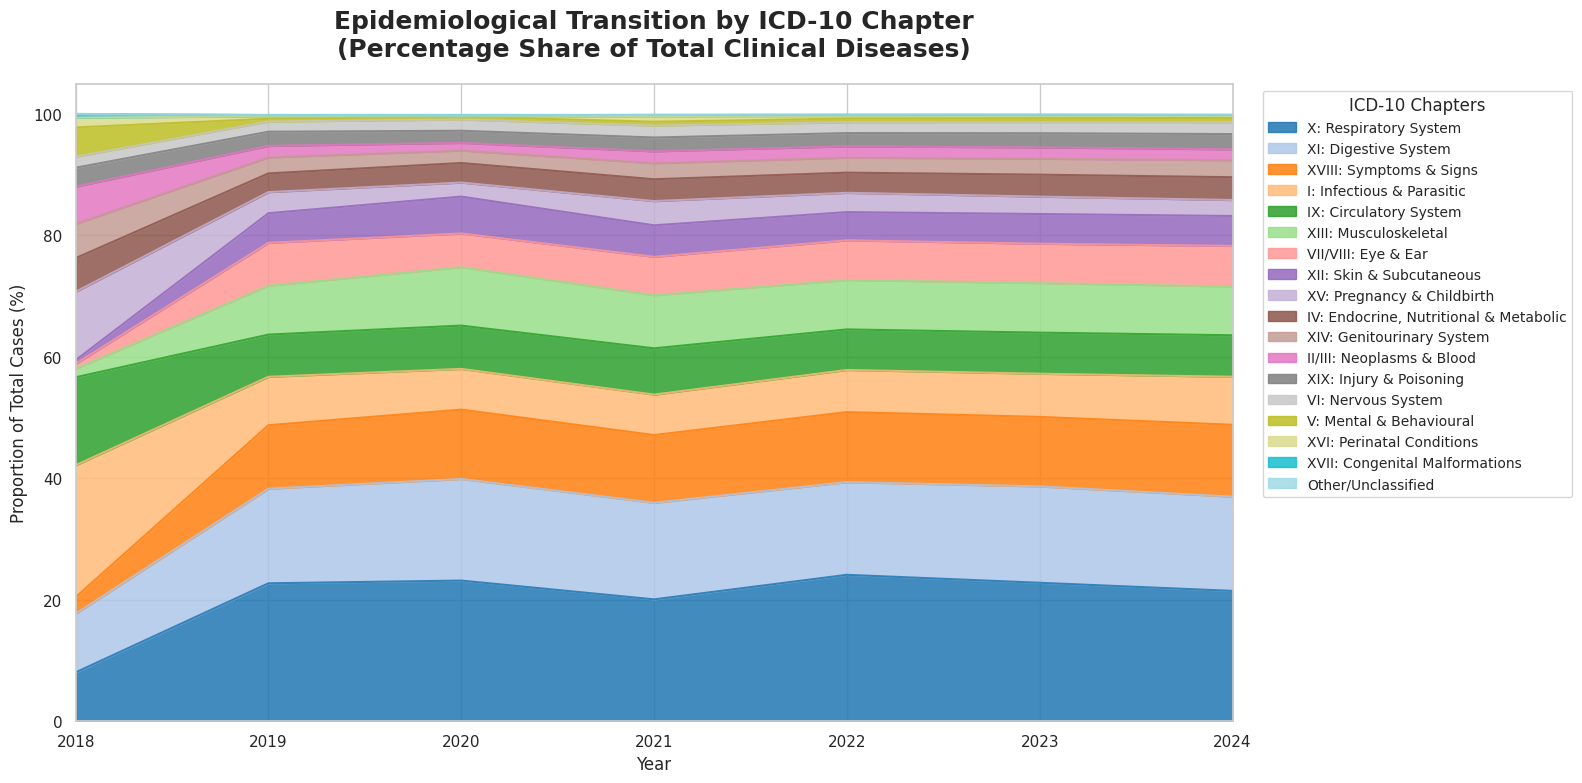


[SUCCESS] Chapter visualization saved to: /content/drive/MyDrive/Data sampel bpjs/Data_Processed/Chapter_Transition_AreaChart_EN.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
#@title VISUALIZATION: DISEASE BURDEN BY ICD-10 CHAPTER (EN)
print("=========================================================")
print("  VISUALIZATION: DISEASE BURDEN BY ICD-10 CHAPTER (EN)   ")
print("=========================================================\n")

# 1. RE-RUN KALKULASI SHARE AGAR TIDAK TERJADI NAME ERROR
print("[PROCESS] Recalculating denominator and new share percentages...")
df_non_z = df_summary[~df_summary['ICD10_CODE'].astype(str).str.startswith('Z', na=False)]
total_non_z_per_tahun = df_non_z.groupby('TAHUN')['COUNT'].sum()

def calculate_share(row):
    if str(row['ICD10_CODE']).startswith('Z'):
        return 0
    else:
        return (row['COUNT'] / total_non_z_per_tahun[row['TAHUN']]) * 100

df_summary['NEW_SHARE'] = df_summary.apply(calculate_share, axis=1)

# 2. FILTER NOISE: Buang Z dan sebab luar (V, W, X, Y) biar murni penyakit
forbidden_chars = ('V', 'W', 'X', 'Y', 'Z')
df_disease = df_summary[~df_summary['ICD10_CODE'].astype(str).str.startswith(forbidden_chars, na=False)].copy()

# 3. MAPPING ICD-10 KE NAMA CHAPTER WHO
def get_icd_chapter(code):
    char = str(code)[0].upper()
    if char in ['A', 'B']: return 'I: Infectious & Parasitic'
    elif char in ['C', 'D']: return 'II/III: Neoplasms & Blood'
    elif char == 'E': return 'IV: Endocrine, Nutritional & Metabolic'
    elif char == 'F': return 'V: Mental & Behavioural'
    elif char == 'G': return 'VI: Nervous System'
    elif char == 'H': return 'VII/VIII: Eye & Ear'
    elif char == 'I': return 'IX: Circulatory System'
    elif char == 'J': return 'X: Respiratory System'
    elif char == 'K': return 'XI: Digestive System'
    elif char == 'L': return 'XII: Skin & Subcutaneous'
    elif char == 'M': return 'XIII: Musculoskeletal'
    elif char == 'N': return 'XIV: Genitourinary System'
    elif char == 'O': return 'XV: Pregnancy & Childbirth'
    elif char == 'P': return 'XVI: Perinatal Conditions'
    elif char == 'Q': return 'XVII: Congenital Malformations'
    elif char == 'R': return 'XVIII: Symptoms & Signs'
    elif char in ['S', 'T']: return 'XIX: Injury & Poisoning'
    else: return 'Other/Unclassified'

print("[PROCESS] Mapping ICD-10 codes to official chapters...")
df_disease['CHAPTER'] = df_disease['ICD10_CODE'].apply(get_icd_chapter)

# 4. AGREGASI & PIVOT: Jumlahkan porsi NEW_SHARE per Tahun dan per Chapter
df_chapter = df_disease.groupby(['TAHUN', 'CHAPTER'])['NEW_SHARE'].sum().reset_index()
pivot_chapter = df_chapter.pivot(index='TAHUN', columns='CHAPTER', values='NEW_SHARE').fillna(0)

# Urutkan kolom dari yang kontribusinya paling besar (berdasarkan rata-rata)
top_chapters = pivot_chapter.mean().sort_values(ascending=False).index
pivot_chapter = pivot_chapter[top_chapters]

print("\n--- SUMMARY TABLE: CHAPTER SHARE (%) ---")
display(pivot_chapter.round(2))

# =====================================================================
# GRAFIK: STACKED AREA CHART
# =====================================================================
print("\n[PROCESS] Rendering Stacked Area Chart...")

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Plot the Stacked Area
pivot_chapter.plot(kind='area', stacked=True, colormap='tab20', alpha=0.85, ax=plt.gca())

# Custom Labels
plt.title('Epidemiological Transition by ICD-10 Chapter\n(Percentage Share of Total Clinical Diseases)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Proportion of Total Cases (%)', fontsize=12)

# Adjust Legend to sit nicely outside the plot
plt.legend(title='ICD-10 Chapters', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.margins(x=0)
plt.tight_layout()

# Save High-Res Image to Drive
path_plot = '/content/drive/MyDrive/Data sampel bpjs/Data_Processed/Chapter_Transition_AreaChart_EN.png'
plt.savefig(path_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[SUCCESS] Chapter visualization saved to: {path_plot}")